# Random library-mutant baseline vs DPO 650M — CDR-H3 generation comparison

We compare two CDR-H3 generators and ask which one produces sequences that the
**PGLD binder scorer** rates highly, and how each one explores sequence space:

- **Naive baseline — random library-mutant sampler.** A deliberately "dumb"
  generator (ported from Lorenz Kaiser's genetic-algorithm seed-pool code). For
  each loop position it records the *set* of residues observed in the `ed2_m22`
  train split (filtered to rows above the WT M22 binding enrichment,
  `protein_design.constants.WT_M22_BINDING_ENRICHMENT`), then builds new
  sequences WT-centered: pick `k ~ Uniform[1, trust_radius]` mutable positions
  and reassign each to a *uniformly-chosen* observed residue. Headline run =
  **trust_radius 11** (matching the DPO beam's `--n-steps 11`), 5000 sequences.
  CPU-only, pure numpy. Unlike the PSSM baseline it is **uniform over observed
  residues**, not frequency-weighted — strictly dumber.
- **Best model — DPO 650M.** Giovanni's DPO checkpoint
  `just_dpo_650M/step_8250.pt` (base ESM2-650M), generated with stochastic beam
  search: `--beam-size 500 --n-steps 11 --snapshot-every 1 --temperature 0.9
  --seed 42 --start-mode wt`.

**Beam-search filtering.** The DPO beam CSV contains snapshots at every step
`gibbs_step ∈ {0..11}`. Step 0 = WT and step 1 = single mutants (ED1) are
uninformative, so the comparison set is configurable via **`DPO_BEAM_STEPS`** (set near the
top of the notebook). The default keeps the rows with `gibbs_step ∈ {2..11}`
(5000 sequences = beam_size 500 × 10 remaining steps); add or remove steps to
change the library (e.g. add 1 to fold in the single mutants), and the DPO
library size — and every DPO number below — scales with the steps chosen. Each beam
step changes one position, so the beam spans up to 11 mutations from WT; the
random baseline is sampled to the same 5000 total for a fair comparison. The full
CSV is kept on disk (for trajectory plots); the filtered subset is written next
to it with a `_filtered` suffix.

The **DPO 650M side is reused unchanged** from the existing PSSM-vs-DPO
comparison (same beam CSV and the same DPO PGLD / UQ / PLL scores); only the
naive-baseline side is new. Everything heavy (beam search, scoring) runs in SLURM
jobs — this notebook only *preflights* (prints the exact `sbatch` command for any
missing artifact) and then visualises the cached outputs. Heavy artifacts live
under a dedicated scratch tree so earlier runs are not clobbered.

## Intuition — what the two generators actually do

The two generators sit at opposite ends of "how much modelling is involved".

### Naive baseline — random library-mutant sampler
**In one sentence:** *for each position of the loop, list the amino acids that
appeared in good binders, then build new sequences by picking a few positions at
random and swapping in another observed residue, uniformly — a dumb,
WT-centered shuffler.*

- **Technically:** ported from Lorenz Kaiser's genetic-algorithm seed-pool code.
  We take the `ed2_m22` train split, keep only sequences scoring **above the WT
  M22 binding enrichment**, and for each of the 24 CDR-H3 positions record the
  *set* of residues observed there (the WT residue is always included). A
  position is **mutable** if more than one residue was observed. To draw one
  sequence we pick `k ~ Uniform[1, trust_radius]` mutable positions and set each
  to a uniformly-chosen observed residue ≠ the current one. The **trust radius**
  caps the number of edits from WT; here it is **11** (matching the DPO beam).
- **How it differs from the PSSM baseline:** the PSSM samples each position from
  its *frequency-weighted* categorical (residues common in good binders are drawn
  more often). The random sampler is **uniform over the observed set** — it
  ignores how often each residue occurred, so it is strictly dumber: it knows
  *which* residues are tolerated at a position but not *which are preferred*.
- **What it can and cannot capture:** like the PSSM it is a **bag of independent
  positions** — blind to **epistasis** (couplings between positions) — but it is
  even less informed, because it does not even use the per-position frequencies.
  It can only recombine residues that were already observed; it cannot discover
  that *a particular combination* of mutations is good. This is the *naive*
  baseline: the dumbest reasonable thing short of fully random sequences.

### Best model — DPO 650M + stochastic beam search
**In one sentence:** *take a protein language model that has been nudged to
prefer good binders over bad ones, and let it iteratively edit the WT, keeping
the most promising candidates at each step.*

- **DPO (Direct Preference Optimization) — the model.** We start from ESM2-650M
  (a transformer masked-language model of proteins). DPO fine-tunes it not on raw
  sequences but on **preference pairs**: given a "winner" (higher-enrichment
  binder) and a "loser" (lower-enrichment), the loss directly raises the model's
  relative likelihood of the winner over the loser — a closed-form, reward-free
  objective with the frozen base model as a KL anchor. The net effect: the
  model's conditional distribution is **reshaped to put probability mass on
  high-affinity sequences**. Because it is a full transformer (not independent
  positions), it can represent **coordinated, epistatic** edits — "mutate 8
  *and* 2 together".
- **Stochastic beam search — the decoder.** The model defines a distribution, not
  a generator, so we draw from it by guided iterative decoding. Start from the
  C05 **WT**; at each step mask/propose substitutions, score candidate sequences
  by model likelihood, and keep a **beam** of the top `B = 500` (with temperature
  `T = 0.9` for diversity). After `N = 11` steps the beam has accumulated
  mutations, having walked toward regions the model considers high-likelihood —
  i.e. predicted strong binders. We snapshot every step (`gibbs_step`); steps 0
  (=WT) and 1 (single mutants) are uninformative, so the comparison set is
  the steps in `DPO_BEAM_STEPS` (default `gibbs_step ∈ {2..11}`).

### Why compare them
The random baseline tells us how far you get with **uniform recombination of the
residues seen in good binders** — no preferences, no couplings. The DPO model
tells us how far you get with a **learned, coupled model of binding** plus a
guided search. The gap between them is the value added by modelling preferences,
epistasis, and search — exactly what the PGLD scorer, the distance-from-WT trend,
and the novelty analysis below quantify.

## Setup

Repo root on `sys.path` (for `src/`), standard imports, matplotlib in `Agg`
(figures render only when explicitly displayed), and the artifact paths used
throughout.

### Generation-protocol alignment with `report/report_plots.ipynb`

The report configuration and this comparison use the same scientific generation
protocol for their shared random and DPO-650M libraries:

| Setting | This comparison | Report generation config | Status |
| --- | --- | --- | --- |
| Random sampler | `ed2_m22` train split, above-WT enrichment alphabet, R=11, 5,000 rows, seed 42, duplicates retained | Same | Matched |
| DPO checkpoint / start | `just_dpo_650m` step 8250 / C05 WT | Same checkpoint / WT start | Matched |
| Stochastic beam | beam 500, 11 steps, snapshots every step, T=0.9, seed 42 | Same | Matched |
| Kept DPO library | steps 2?11 (5,000 rows) | Same | Matched |

The random sweep additionally generates R=2, 4, 6, and 8 only for the
quality?diversity curve; the R=11 library is the report-matched comparison
library. The report's `top_k=50` is an evaluation summary setting, not a
sampling parameter.

`template_batch_size` is intentionally not a protocol setting: the report's
A100-80GB profile uses 384 while this generic 32GB launcher defaults to 1. It
changes GPU throughput only, not the generated distribution. On a suitable
A100-80GB allocation, submit the beam job with
`BEAM_TEMPLATE_BATCH_SIZE=384 sbatch ...` to also match that execution profile.


In [1]:
import os
import sys, pathlib, subprocess

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'pyproject.toml').exists():
    if REPO.parent == REPO:  # reached filesystem root without finding the repo
        raise RuntimeError(
            f"Could not locate the repo root (no pyproject.toml above {pathlib.Path.cwd()}). "
            "Start Jupyter from inside the protein-design checkout."
        )
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'src'))

import numpy as np
import pandas as pd
import yaml
import matplotlib
matplotlib.use('Agg')  # non-interactive: figures render only via save_show_fig()
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from IPython.display import Image, display

from protein_design.constants import WT_M22_BINDING_ENRICHMENT, C05_CDRH3
from protein_design.analysis.novelty import (
    build_reference_index,
    annotate_sequence_membership,
)

print(f'REPO          = {REPO}')
print(f'WT M22 enrich = {WT_M22_BINDING_ENRICHMENT}')
print(f'WT CDR-H3     = {C05_CDRH3}')

# --- scratch trees for the regenerable heavy artifacts ---
# SCRATCH_DIR comes from .env.local; the fallback keeps notebook execution
# portable without writing into another user's scratch directory.
SCRATCH_ROOT = Path(os.environ.get(
    'SCRATCH_DIR', f"/cluster/scratch/{os.environ.get('USER', 'unknown')}/protein-design"
))
# The RANDOM baseline side is new and lives in its own scratch tree.
SCRATCH = SCRATCH_ROOT / 'random_vs_dpo_650m'
# The DPO 650M side is generator-independent and is REUSED UNCHANGED from the
# existing PSSM-vs-DPO comparison: the same beam CSV, the same DPO PGLD/UQ/PLL
# scores, and the same WT scores. We never regenerate or rescore it here.
DPO_SCRATCH = SCRATCH_ROOT / 'pssm_vs_dpo_650m'
print(f'SCRATCH_ROOT  = {SCRATCH_ROOT}')

# DPO 650M beam search (CSV reused; the filtered subset is re-derived into the
# new tree by the data-prep cell below -- identical content, fresh location).
BEAM_DPO_CSV      = DPO_SCRATCH / 'beam_dpo' / 'beam_dpo_650m_step8250.csv'
BEAM_DPO_FILTERED = SCRATCH / 'beam_dpo' / 'beam_dpo_650m_step8250_filtered.csv'
DPO_CHECKPOINT    = '/cluster/project/infk/krause/gguidarini/protein-design/checkpoints/just_dpo_650M/step_8250.pt'

# Random library-mutant baseline sweep (trust_radius=11 is the headline run)
RANDOM_SWEEP_DIR   = SCRATCH / 'random_sweep'
RANDOM_R11_CSV     = RANDOM_SWEEP_DIR / 'radius_11' / 'random_output.csv'
RANDOM_ENTROPY_PNG = RANDOM_SWEEP_DIR / 'plots' / 'summary' / 'random_entropy_heatmap.png'
RANDOM_JSD_PNG     = RANDOM_SWEEP_DIR / 'plots' / 'summary' / 'random_jsd_vs_radius.png'

# PGLD scores
SCORES_DIR        = SCRATCH / 'scores'                                              # random-baseline scores (new)
DPO_SCORES_CSV    = DPO_SCRATCH / 'scores' / 'dpo_650m_step8250_filtered_m22.csv'   # reused
RANDOM_SCORES_CSV = SCORES_DIR / 'random_R11_m22.csv'
WT_SCORE_CSV      = DPO_SCRATCH / 'scores' / 'wt_m22.csv'                           # generator-independent (reused)

# Reference: PGLD scores of the ed2_m22 test split (cache managed by
# score_dms_with_esme.py at $cache_root/scorer_preds/<dataset>/<scorer>.csv).
_dms_cfg = yaml.safe_load((REPO / 'conf' / 'analysis' / 'dms_datasets.yaml').open())
_cache_root = Path(_dms_cfg['paths']['cache_root'])
REF_SCORE_CSV = _cache_root / 'scorer_preds' / 'ed2_m22' / 'm22.csv'
REF_SEQ_COL   = _dms_cfg['datasets']['ed2_m22']['seq_col']  # 'aa'

# Model-free diagnostics output (gibbs_diagnostics.py) for the side-by-side view
DIAG_DIR = SCRATCH / 'diagnostics'

# Vector figures produced by this notebook
FIG_DIR = REPO / 'report' / 'figures' / 'random_vs_dpo_650m'

GEN_SEQ_COL = 'cdrh3'  # sequence column in both generated CSVs

# Shared publication style; keep all notebook figures visually consistent with
# report/plots.md. MathText avoids a fragile external LaTeX dependency.
SINGLE_COL_WIDTH = 3.35
DOUBLE_COL_WIDTH = 7.0
COLORS = {
    'green': '#1B9E77',
    'orange': '#D95F02',
    'blue': '#5E81AC',
    'purple': '#7570B3',
    'pink': '#E65A9A',
    'grey': '#8A8A8A',
    'dark': '#2B2B2B',
}
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Latin Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    'font.size': 10.5,
    'axes.titlesize': 12.5,
    'axes.labelsize': 11.5,
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'legend.fontsize': 9.5,
    'figure.titlesize': 13.0,
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'lines.linewidth': 1.8,
    'lines.markersize': 5.0,
    'legend.frameon': True,
    'legend.framealpha': 0.92,
    'legend.fancybox': False,
    'legend.edgecolor': '0.80',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


def style_axes(ax):
    """Apply the report's common axes treatment without changing plot data."""
    if not ax.axison or ax.get_label() == '<colorbar>':
        return
    ax.tick_params(axis='both', which='major', width=0.8, length=3.5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.set_axisbelow(True)
    if ax.has_data():
        ax.grid(False, axis='x')
        ax.grid(axis='y', color='0.90', linewidth=0.6, zorder=0)
        if ax.get_yscale() == 'linear':
            ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    legend = ax.get_legend()
    if legend is not None:
        legend.set_frame_on(True)
        legend.get_frame().set_alpha(0.92)
        legend.get_frame().set_edgecolor('0.80')


def style_figure(fig):
    for ax in fig.axes:
        style_axes(ax)
    fig.align_labels()
    for text in fig.findobj(match=matplotlib.text.Text):
        text.set_fontsize(max(9.5, text.get_fontsize()))


def save_show_fig(fig, name, dpi=400):
    """Save matching vector PDF and high-resolution PNG files, then show PNG only."""
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    pdf = FIG_DIR / f'{name}.pdf'
    png = FIG_DIR / f'{name}.png'
    style_figure(fig)
    fig.savefig(pdf, format='pdf', bbox_inches='tight', pad_inches=0.03)
    fig.savefig(png, format='png', dpi=dpi, bbox_inches='tight', pad_inches=0.03)
    plt.close(fig)
    print(f'Saved PDF: {pdf}')
    print(f'Saved PNG: {png}')
    display(Image(filename=str(png)))
print('Paths configured. Figures -> ', FIG_DIR)

REPO          = /cluster/home/gguidarini/protein-design
WT M22 enrich = 5.190013461
WT CDR-H3     = HMSMQQVVSAGWERADLVGDAFDV
SCRATCH_ROOT  = /cluster/scratch/gguidarini/protein-design
Paths configured. Figures ->  /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m


## Preflight — generation artifacts

Check the three inputs we need before any analysis: the DPO 650M beam CSV, the
random baseline `trust_radius = 11` CSV, and the reference PGLD scores for the `ed2_m22` test split.
For any missing one we print the exact `sbatch` command (we do **not** submit it
automatically). If anything is missing the cell raises so downstream cells do
not run on absent data — submit the jobs, then re-run the notebook.

In [2]:
def check_artifact(path, description, sbatch_cmd):
    """Print existence + the sbatch fallback for one artifact; return bool."""
    path = Path(path)
    exists = path.exists()
    print(f"[{'OK     ' if exists else 'MISSING'}] {description}")
    print(f"          {path}")
    if not exists:
        print(f"          -> generate with:\n             {sbatch_cmd}")
    print()
    return exists

gen_ok = [
    check_artifact(
        BEAM_DPO_CSV,
        'DPO 650M beam search (all gibbs steps) - reused from PSSM-vs-DPO',
        'sbatch bash_scripts/utils/beam_search_dpo_650m_step8250.sbatch',
    ),
    check_artifact(
        RANDOM_R11_CSV,
        'Random library-mutant baseline sweep (trust_radius=11 headline = 5000 seqs)',
        'sbatch bash_scripts/utils/run_random_baseline_sweep_dpo_comparison.sbatch',
    ),
    check_artifact(
        REF_SCORE_CSV,
        'Reference PGLD scores for ed2_m22 test split',
        'sbatch bash_scripts/utils/score_dms.sbatch --dataset ed2_m22',
    ),
]
if not all(gen_ok):
    raise FileNotFoundError(
        'Missing generation artifact(s) above - submit the printed sbatch job(s), '
        'then re-run this notebook.'
    )
print('All generation artifacts present.')

[OK     ] DPO 650M beam search (all gibbs steps) - reused from PSSM-vs-DPO
          /cluster/scratch/gguidarini/protein-design/pssm_vs_dpo_650m/beam_dpo/beam_dpo_650m_step8250.csv

[OK     ] Random library-mutant baseline sweep (trust_radius=11 headline = 5000 seqs)
          /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/random_sweep/radius_11/random_output.csv

[OK     ] Reference PGLD scores for ed2_m22 test split
          /cluster/project/infk/krause/mdenegri/protein-design/cache/scorer_preds/ed2_m22/m22.csv

All generation artifacts present.


## Data prep

Load the full DPO beam CSV, keep the beam steps listed in `DPO_BEAM_STEPS`
(default `gibbs_step ∈ {2..11}`), and write the filtered
subset next to it (used as "the ~5000 generated sequences" everywhere
downstream). Load the random baseline `T = 0.9` CSV as-is (its `gibbs_step` is always 0,
it is not a trajectory).

### Edit-budget control (optional)

The DPO beam search and the random library-mutant baseline do not span the same
number of mutations by construction: each beam step changes exactly one position,
so the beam reaches at most `--n-steps` edits from WT (run here with **11
steps**), while the random baseline draws `k ~ Uniform[1, trust_radius]` edits
per sequence, so at the headline **trust_radius 11** it spans 1–11 edits from WT
(it never emits WT itself). To compare the two at a *matched edit budget*, set
`MAX_N_MUTATIONS` in the next cell — both libraries are then restricted to
sequences with at most that many mutations **everywhere downstream**
(diagnostics, scoring, novelty, and the trust-radius/frontier views). Leave it
`None` for the full libraries.

In [3]:
# ============================================================================
# Fair-comparison knob — cap on the number of mutations from the C05 WT.
# ============================================================================
# Set MAX_N_MUTATIONS = K to keep only DPO and random baseline sequences with n_mutations<=K
# in every view below. None disables the cap (full libraries).
MAX_N_MUTATIONS = None        # e.g. 5, 6, 8 ...  or None for no cap

def apply_mut_cap(df, label, *, verbose=True):
    """Filter a generated-sequence frame to n_mutations <= MAX_N_MUTATIONS."""
    if MAX_N_MUTATIONS is None:
        return df
    kept = df[df['n_mutations'] <= MAX_N_MUTATIONS].copy()
    if verbose:
        avail = int(df['n_mutations'].max()) if len(df) else 0
        print(f'[mut-cap] {label}: kept {len(kept)}/{len(df)} rows '
              f'(n_mutations <= {MAX_N_MUTATIONS}; max available = {avail})')
    return kept

print(f'MAX_N_MUTATIONS = {MAX_N_MUTATIONS}'
      + ('  (no cap — full libraries)' if MAX_N_MUTATIONS is None else ''))

# ============================================================================
# Novelty filter — restrict analysis to sequences not in the training data.
# ============================================================================
# Training-set overlaps can inflate scorer predictions and bias the UQ scorer:
# sequences the ensemble "knows" receive artificially low epistemic uncertainty
# but carry no signal for the downstream design task.
NOVEL_ONLY = True

print(f'NOVEL_ONLY      = {NOVEL_ONLY}'
      + ('  (training-set sequences excluded)' if NOVEL_ONLY else '  (all sequences kept)'))

# ============================================================================
# DPO beam-step selection — which beam (Gibbs) steps form the DPO library.
# ============================================================================
# The DPO 650M beam search snapshots every step (gibbs_step 0..11): step 0 = WT,
# step 1 = single mutants (ED1), steps 2..11 = the deeper, multi-mutation edits.
# DPO_BEAM_STEPS is the single source of truth for which steps make up the DPO
# library `dpo_df` used everywhere below — add or remove values to taste (e.g.
# add 1 to fold in the single mutants). Default = steps 2..11 (~500 seqs/step).
#
# NOTE: the DPO library size — and therefore every DPO point, curve and
# diversity number below — scales with the steps chosen. Any non-default
# selection writes step-tagged CSVs (filtered set + scores) so it never silently
# reuses the default set's scores; the score-artifact preflight cells will then
# print the sbatch command(s) needed to (re)score the new selection.
DPO_BEAM_STEPS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

_DEFAULT_DPO_BEAM_STEPS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

def dpo_step_tag(steps=None):
    """Filename tag encoding the beam-step selection ('' for the default 2..11)."""
    steps = sorted(set(DPO_BEAM_STEPS if steps is None else steps))
    return '' if steps == _DEFAULT_DPO_BEAM_STEPS else '_steps' + '-'.join(map(str, steps))

def tag_dpo_path(p):
    """Insert dpo_step_tag() right after '_filtered' in a DPO artifact path."""
    from pathlib import Path
    p = Path(p)
    return p.with_name(p.name.replace('_filtered', f'_filtered{dpo_step_tag()}'))

print(f'DPO_BEAM_STEPS = {DPO_BEAM_STEPS}'
      + ('  (default 2..11)' if dpo_step_tag() == '' else f'  -> file tag "{dpo_step_tag()}"'))


MAX_N_MUTATIONS = None  (no cap — full libraries)
NOVEL_ONLY      = True  (training-set sequences excluded)
DPO_BEAM_STEPS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]  (default 2..11)


In [4]:
# Route this beam-step selection to its own (step-tagged) filtered CSV + score
# CSVs so a non-default DPO_BEAM_STEPS never silently reuses the default set's
# scores. For the default 2..11 the tag is empty and the original names are kept.
BEAM_DPO_FILTERED = tag_dpo_path(BEAM_DPO_FILTERED)
DPO_SCORES_CSV    = tag_dpo_path(DPO_SCORES_CSV)

dpo_full = pd.read_csv(BEAM_DPO_CSV)
print(f'DPO beam (all steps): {len(dpo_full)} rows; '
      f'gibbs_step values = {sorted(dpo_full["gibbs_step"].unique())}')

dpo_df = dpo_full[dpo_full['gibbs_step'].isin(DPO_BEAM_STEPS)].copy()
dpo_df = apply_mut_cap(dpo_df, f'DPO beam (steps {DPO_BEAM_STEPS})')
BEAM_DPO_FILTERED.parent.mkdir(parents=True, exist_ok=True)
dpo_df.to_csv(BEAM_DPO_FILTERED, index=False)
print(f'DPO filtered (steps {DPO_BEAM_STEPS}) -> {BEAM_DPO_FILTERED}: {len(dpo_df)} rows')

rand_full = pd.read_csv(RANDOM_R11_CSV)
rand_df = apply_mut_cap(rand_full, 'Random R=11')

# The side-by-side diagnostics read CSVs from disk, so when a cap is active we
# write a capped random baseline CSV and point the diagnostics at it; otherwise we reuse the
# original file untouched.
if MAX_N_MUTATIONS is None:
    RANDOM_COMPARE_CSV = RANDOM_R11_CSV
else:
    RANDOM_COMPARE_CSV = BEAM_DPO_FILTERED.parent / 'random_R11_capped.csv'
    rand_df.to_csv(RANDOM_COMPARE_CSV, index=False)
print(f'Random R=11: {len(rand_df)} rows (diagnostics csv: {RANDOM_COMPARE_CSV})')

# Unique-sequence frames (one row per cdrh3, carrying n_mutations) for scoring/merges.
dpo_seqs  = dpo_df.drop_duplicates(GEN_SEQ_COL)[[GEN_SEQ_COL, 'n_mutations']].reset_index(drop=True)
rand_seqs = rand_df.drop_duplicates(GEN_SEQ_COL)[[GEN_SEQ_COL, 'n_mutations']].reset_index(drop=True)
print(f'unique cdrh3 — DPO: {len(dpo_seqs)}, random baseline: {len(rand_seqs)}')

DPO beam (all steps): 5457 rows; gibbs_step values = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
DPO filtered (steps [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]) -> /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/beam_dpo/beam_dpo_650m_step8250_filtered.csv: 5000 rows
Random R=11: 5000 rows (diagnostics csv: /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/random_sweep/radius_11/random_output.csv)
unique cdrh3 — DPO: 3934, random baseline: 4840


## Preflight — scoring artifacts

Same pattern, but for the PGLD score CSVs of the two generated sets. The DPO
score job reads the *filtered* CSV written above, so run the data-prep cell
first. As before, missing artifacts print their `sbatch` command and raise.

In [5]:
score_ok = [
    check_artifact(
        DPO_SCORES_CSV,
        'PGLD scores - DPO filtered set (reused)',
        f'sbatch bash_scripts/utils/score_generated_with_esme.sbatch '
        f'--input-csv {BEAM_DPO_FILTERED} --output-csv {DPO_SCORES_CSV}',
    ),
    check_artifact(
        RANDOM_SCORES_CSV,
        'PGLD scores - random R=11 set',
        f'sbatch bash_scripts/utils/score_generated_with_esme.sbatch '
        f'--input-csv {RANDOM_R11_CSV} --output-csv {RANDOM_SCORES_CSV}',
    ),
]
if not all(score_ok):
    raise FileNotFoundError(
        'Missing score artifact(s) above - submit the printed sbatch job(s), '
        'then re-run this notebook.'
    )
print('All score artifacts present.')

[MISSING] PGLD scores - DPO filtered set (reused)
          /cluster/scratch/gguidarini/protein-design/pssm_vs_dpo_650m/scores/dpo_650m_step8250_filtered_m22.csv
          -> generate with:
             sbatch bash_scripts/utils/score_generated_with_esme.sbatch --input-csv /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/beam_dpo/beam_dpo_650m_step8250_filtered.csv --output-csv /cluster/scratch/gguidarini/protein-design/pssm_vs_dpo_650m/scores/dpo_650m_step8250_filtered_m22.csv

[MISSING] PGLD scores - random R=11 set
          /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/scores/random_R11_m22.csv
          -> generate with:
             sbatch bash_scripts/utils/score_generated_with_esme.sbatch --input-csv /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/random_sweep/radius_11/random_output.csv --output-csv /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/scores/random_R11_m22.csv



FileNotFoundError: Missing score artifact(s) above - submit the printed sbatch job(s), then re-run this notebook.

## Broad-strokes comparison (before the scorer)

Model-free views of how the two generators explore CDR-H3 space.

### Novelty — how much is already in the training data?

A generated CDR-H3 counts as **novel** only if it does **not** appear in the
**training data** the generators were built from — i.e. the `train` split of
the configured DMS datasets (`{ed2,ed5,ed811}_m22`, `{ed2,ed5}_si06`), pulled by
`build_reference_index(REPO, splits={'train'})`.

This is the strict, memorization-style definition: a sequence the model could
have simply copied from its training set is not a new design, even if it scores
well. We deliberately do **not** count the val/test splits or the `exp` set —
those were never seen during training, so reproducing them would be genuine
rediscovery, not memorization.

,model,n_unique,n_in_training_data,frac_in_training_data,frac_novel
0,Random (R=11),4840,569,0.118,0.882
1,DPO 650M,3934,483,0.123,0.877


Saved PDF: /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m/novelty_overlap.pdf
Saved PNG: /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m/novelty_overlap.png


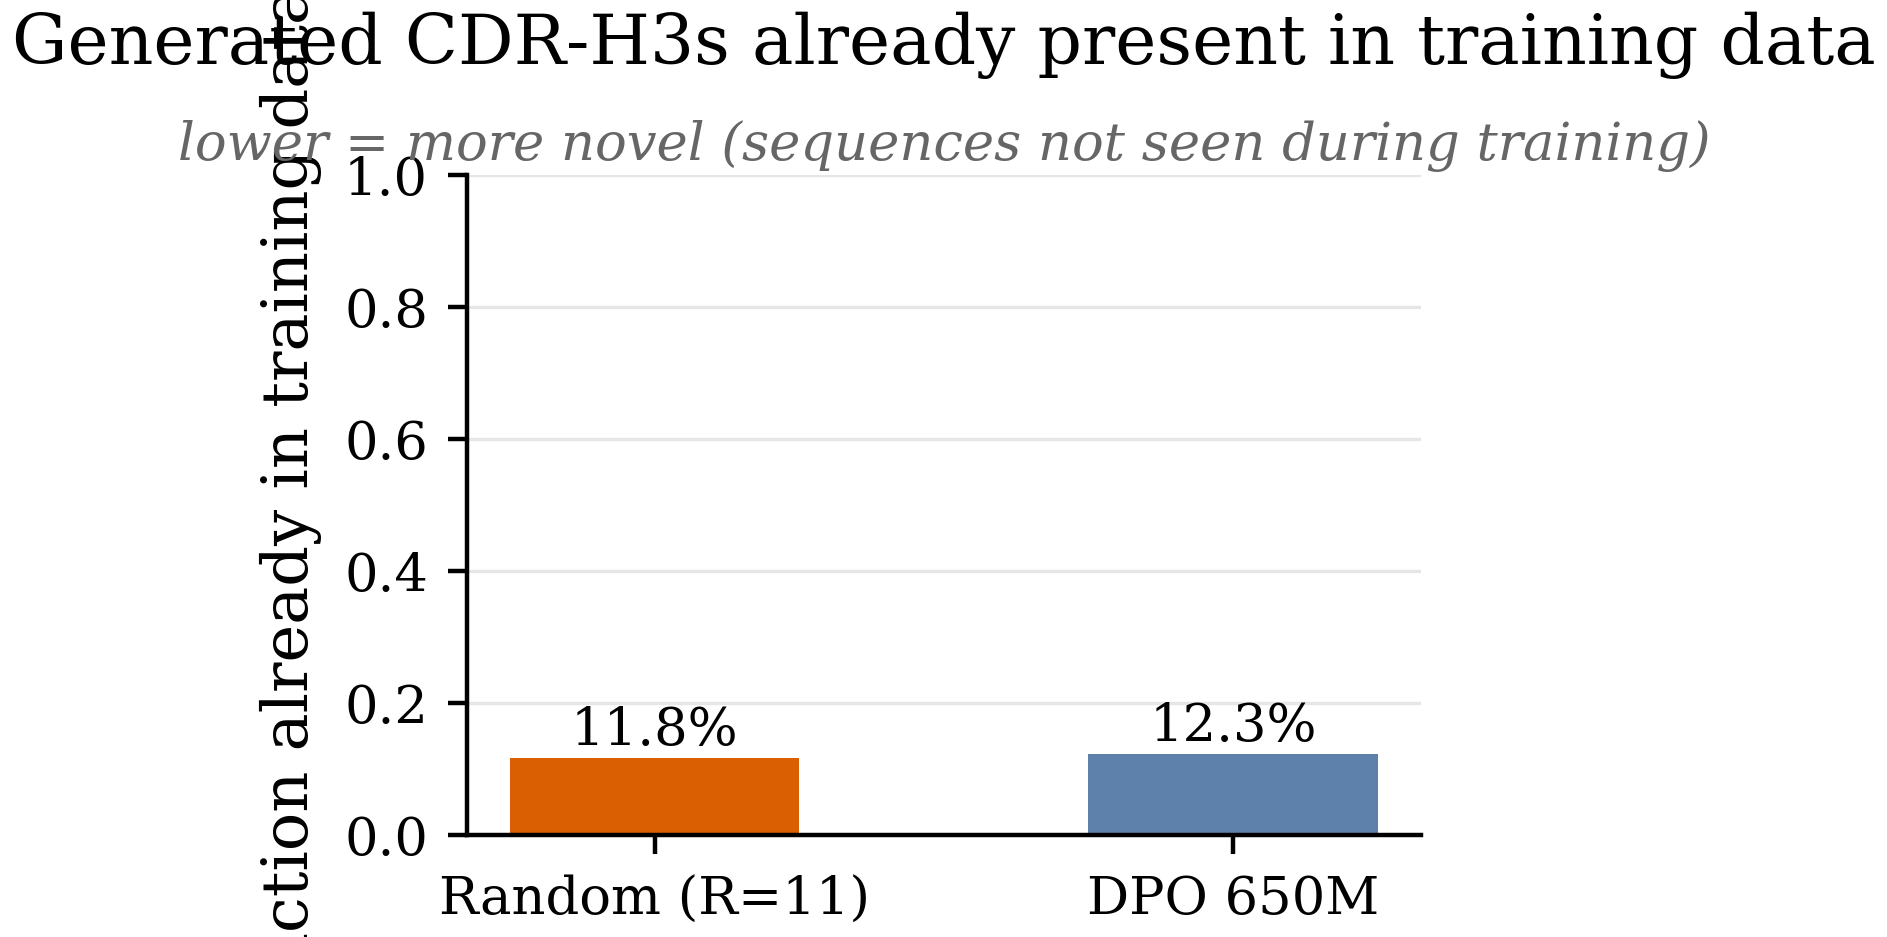

In [6]:
# Novelty is defined against the TRAINING data: a generated CDR-H3 is "novel"
# only if it does not appear in the train split the generators were built from
# (train split of every configured DMS dataset; see markdown above).
ref_index_train = build_reference_index(REPO, splits={'train'})

dpo_annot  = annotate_sequence_membership(dpo_seqs,  seq_col=GEN_SEQ_COL, reference_index=ref_index_train)
rand_annot = annotate_sequence_membership(rand_seqs, seq_col=GEN_SEQ_COL, reference_index=ref_index_train)

def novelty_row(name, annot):
    n = len(annot)
    seen = int(annot['present_in_existing_dataset'].sum())
    return {'model': name, 'n_unique': n,
            'n_in_training_data': seen,
            'frac_in_training_data': seen / n if n else float('nan'),
            'frac_novel': (n - seen) / n if n else float('nan')}

novelty = pd.DataFrame([novelty_row('Random (R=11)', rand_annot),
                        novelty_row('DPO 650M', dpo_annot)])
display(novelty.round(3))

# Bar per model: fraction of unique generated CDR-H3s already in the train data.
models = novelty['model'].tolist()
fig, ax = plt.subplots(figsize=(SINGLE_COL_WIDTH, 2.6))
bars = ax.bar(models, novelty['frac_in_training_data'], width=0.5,
              color=[COLORS['orange'], COLORS['blue']])  # random baseline orange, DPO blue (Okabe-Ito)
ax.set_ylabel('Train fraction')
ax.set_ylim(0, 1)
ax.set_title('Generated CDR-H3s already present in training data', pad=20)
ax.text(0.5, 1.005, 'lower = more novel (sequences not seen during training)',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=7, style='italic', color='0.4')
for rect, v in zip(bars, novelty['frac_in_training_data']):
    ax.text(rect.get_x() + rect.get_width() / 2, v + 0.02, f'{v:.1%}',
            ha='center', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'novelty_overlap')

In [7]:
# Apply the NOVEL_ONLY filter before any scoring or analysis.
# dpo_seqs / rand_seqs are re-bound to novel-only subsets; the novelty_overlap
# figure above already used the full annotated frames and is unaffected.
if NOVEL_ONLY:
    _n_dpo  = len(dpo_seqs)
    _n_rand = len(rand_seqs)
    _novel_dpo  = set(dpo_annot.loc[~dpo_annot['present_in_existing_dataset'], GEN_SEQ_COL])
    _novel_rand = set(rand_annot.loc[~rand_annot['present_in_existing_dataset'], GEN_SEQ_COL])
    dpo_seqs  = dpo_seqs[dpo_seqs[GEN_SEQ_COL].isin(_novel_dpo)].reset_index(drop=True)
    rand_seqs = rand_seqs[rand_seqs[GEN_SEQ_COL].isin(_novel_rand)].reset_index(drop=True)
    print('[NOVEL_ONLY=True]')
    print(f'  DPO   : {_n_dpo:,} -> {len(dpo_seqs):,}  ({_n_dpo - len(dpo_seqs):,} train-overlap sequences removed)')
    print(f'  Random: {_n_rand:,} -> {len(rand_seqs):,}  ({_n_rand - len(rand_seqs):,} train-overlap sequences removed)')
else:
    print('[NOVEL_ONLY=False] All sequences kept (including training-data overlaps).')


def keep_novel(df, seq_col=GEN_SEQ_COL):
    """Drop rows whose sequence appears in the training data (ref_index_train).
    No-op when NOVEL_ONLY is False. Duplicate-safe: membership is decided on the
    unique sequences, then applied back to the (possibly duplicated) input rows,
    so duplicate-weighted means and diversity counts stay correct. Used by the
    quality-vs-diversity frontier cells, which read sweep CSVs straight from disk
    (bypassing dpo_seqs / pssm_seqs) and so need the filter applied explicitly."""
    if not NOVEL_ONLY:
        return df
    ann = annotate_sequence_membership(df.drop_duplicates(seq_col),
                                       seq_col=seq_col, reference_index=ref_index_train)
    novel = set(ann.loc[~ann['present_in_existing_dataset'], seq_col])
    return df[df[seq_col].isin(novel)].reset_index(drop=True)


[NOVEL_ONLY=True]
  DPO   : 3,934 -> 3,451  (483 train-overlap sequences removed)
  Random: 4,840 -> 4,271  (569 train-overlap sequences removed)


### Per-position / per-mutation diagnostics (side-by-side)

We invoke `gibbs_diagnostics.py` once with both generators tagged
(`random=unused=<random csv>` and `dpo=<checkpoint>=<dpo filtered csv>`),
`--skip-pll --skip-early` (model-free — no GPU). This emits, side by side:
the sequence logo (per-position AA frequency), the `position_mutation_freq`
heatmap (P(non-WT) per position), the `edit_distance` histogram (Hamming from
the C05 WT), and the `pairwise_hamming` histogram.

In [8]:
FIG_DIR.mkdir(parents=True, exist_ok=True)

# gibbs_diagnostics writes a fixed set of files; run it once per format so we get
# vector PDFs (saved) plus PNGs (for inline display) side by side in FIG_DIR.
def run_diagnostics(fmt):
    cmd = [
        'uv', 'run', 'python', 'scripts/analysis/gibbs_diagnostics.py',
        '--gibbs', f'random=unused={RANDOM_COMPARE_CSV}',
        '--gibbs', f'dpo={DPO_CHECKPOINT}={BEAM_DPO_FILTERED}',
        '--skip-pll', '--skip-early',
        '--sampler-label', 'comparison',
        '--format', fmt,
        '--output-dir', str(FIG_DIR),
    ]
    if fmt == 'pdf':
        print(' '.join(cmd))
    subprocess.run(cmd, check=True, cwd=REPO)

run_diagnostics('pdf')
run_diagnostics('png')
print('diagnostics (pdf + png) written to', FIG_DIR)

uv run python scripts/analysis/gibbs_diagnostics.py --gibbs random=unused=/cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/random_sweep/radius_11/random_output.csv --gibbs dpo=/cluster/project/infk/krause/gguidarini/protein-design/checkpoints/just_dpo_650M/step_8250.pt=/cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/beam_dpo/beam_dpo_650m_step8250_filtered.csv --skip-pll --skip-early --sampler-label comparison --format pdf --output-dir /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m


2026-09-18 17:38:54,986 INFO Device: cpu
2026-09-18 17:38:54,988 INFO === random (1 configs) ===
2026-09-18 17:38:54,988 INFO --- random | config=default ---
2026-09-18 17:38:55,017 INFO Gibbs samples: 5000 (median edit distance from WT = 6)
/cluster/home/gguidarini/protein-design/scripts/analysis/gibbs_diagnostics.py:886: RuntimeWarning: All-NaN slice encountered
  "gibbs_pll_median": float(np.nanmedian(gibbs_pll)) if len(gibbs_pll) else float("nan"),
2026-09-18 17:38:55,063 INFO === dpo (1 configs) ===
2026-09-18 17:38:55,064 INFO --- dpo | config=default ---
2026-09-18 17:38:55,086 INFO Gibbs samples: 5000 (median edit distance from WT = 6)
/cluster/home/gguidarini/protein-design/scripts/analysis/gibbs_diagnostics.py:886: RuntimeWarning: All-NaN slice encountered
  "gibbs_pll_median": float(np.nanmedian(gibbs_pll)) if len(gibbs_pll) else float("nan"),
2026-09-18 17:38:55,128 INFO Configs present: ['default']
2026-09-18 17:38:56,639 INFO Wrote /cluster/home/gguidarini/protein-design/

diagnostics (pdf + png) written to /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m


Saved PDF: /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m/comparison_sequence_logo.pdf


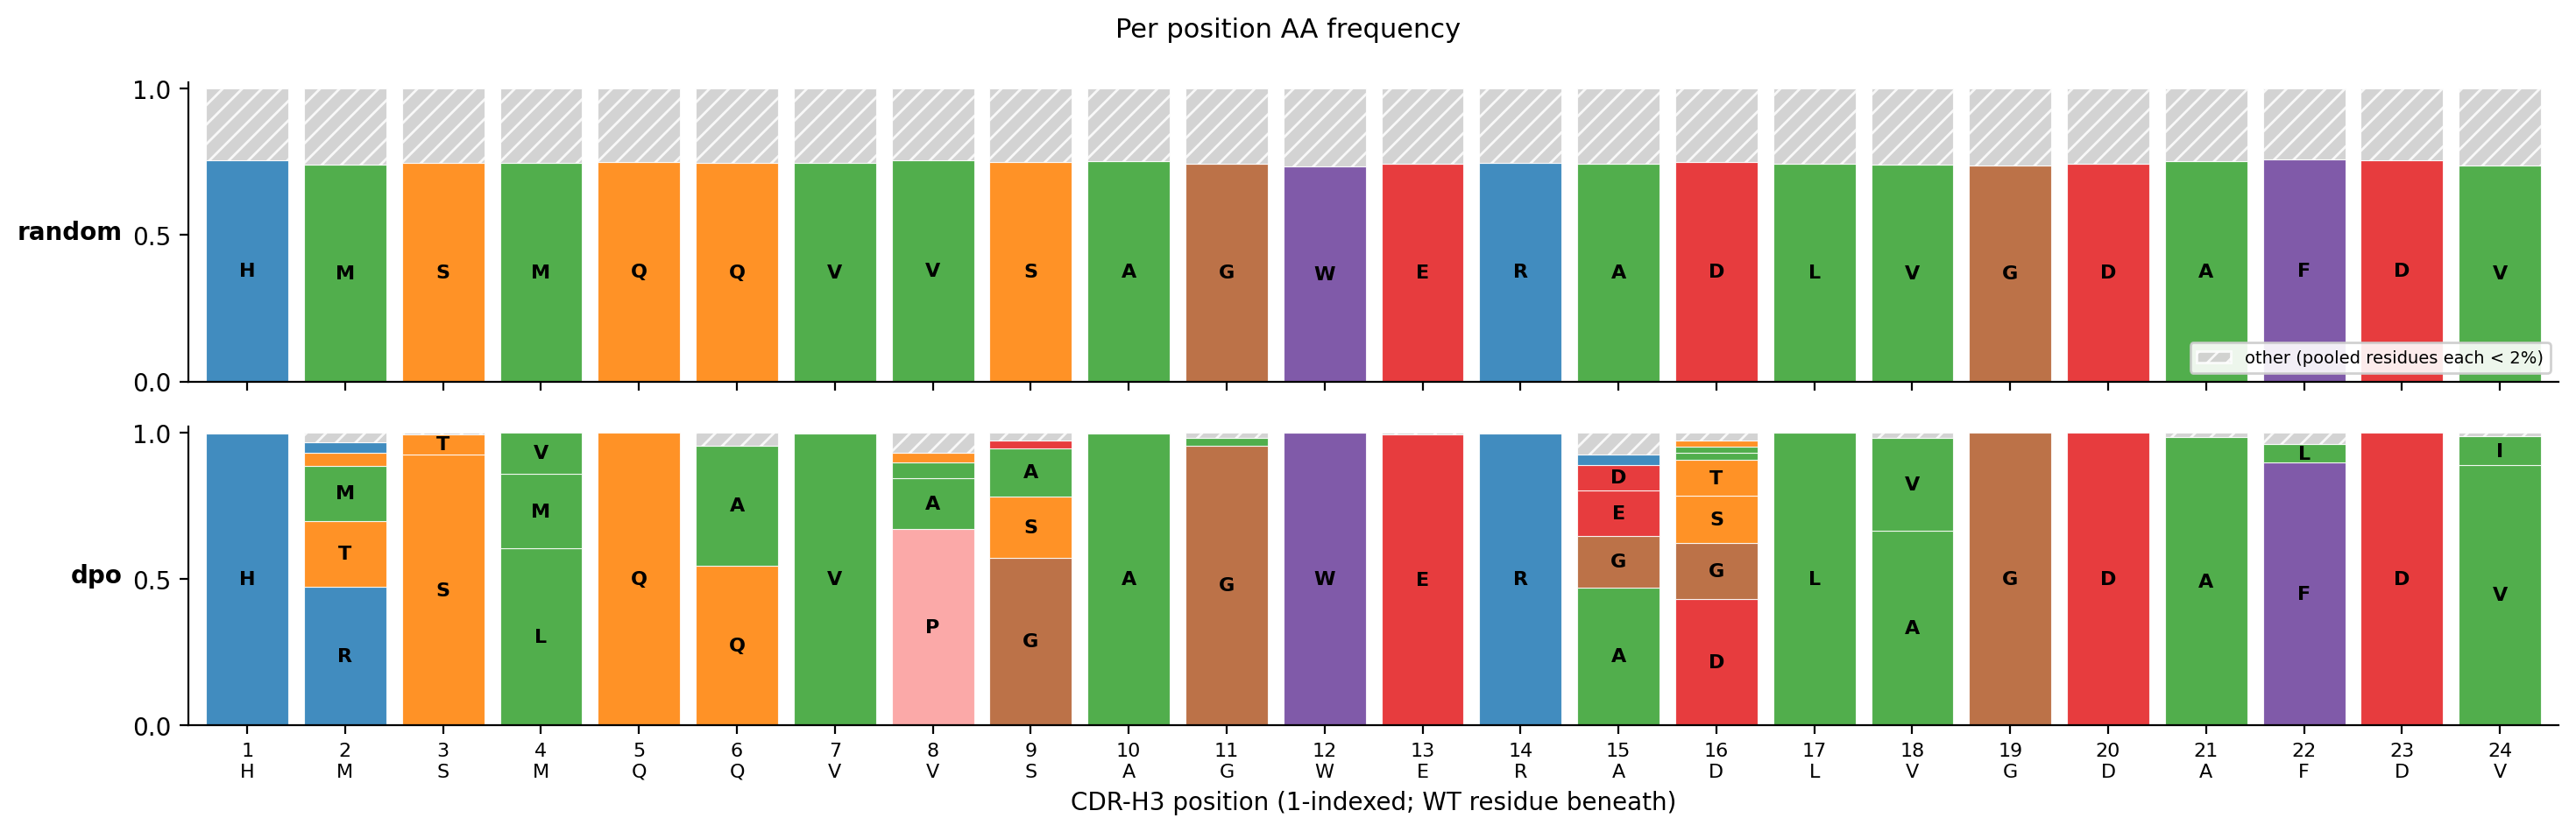

Saved PDF: /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m/comparison_position_mutation_freq.pdf


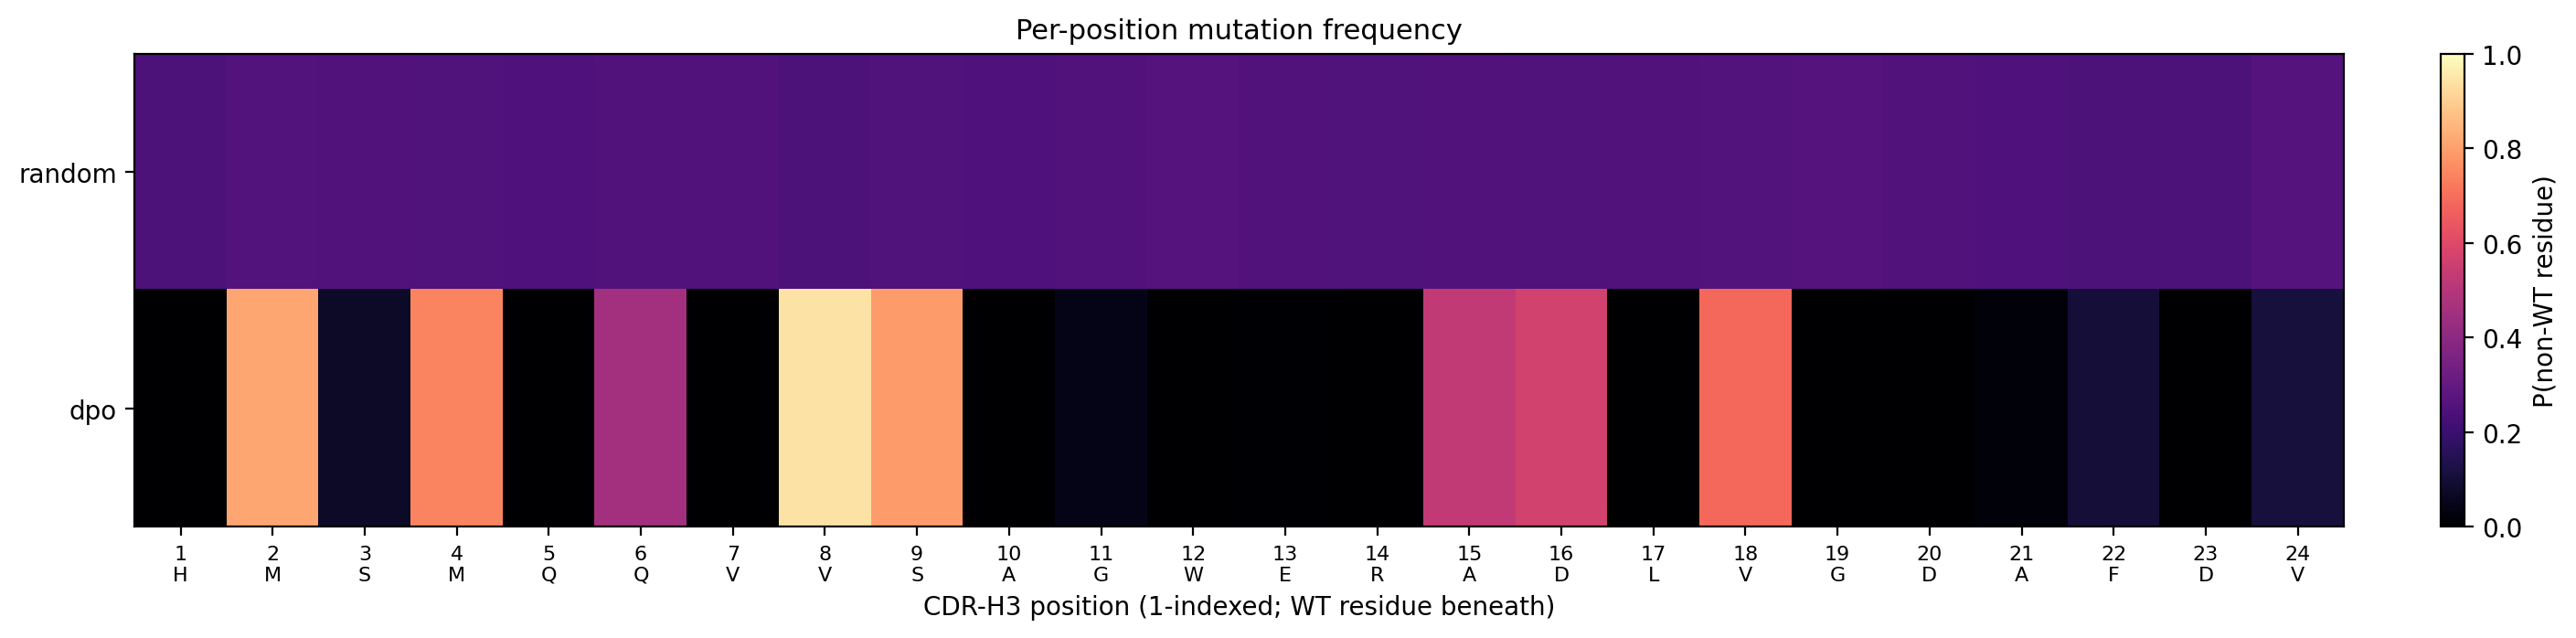

Saved PDF: /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m/comparison_edit_distance.pdf


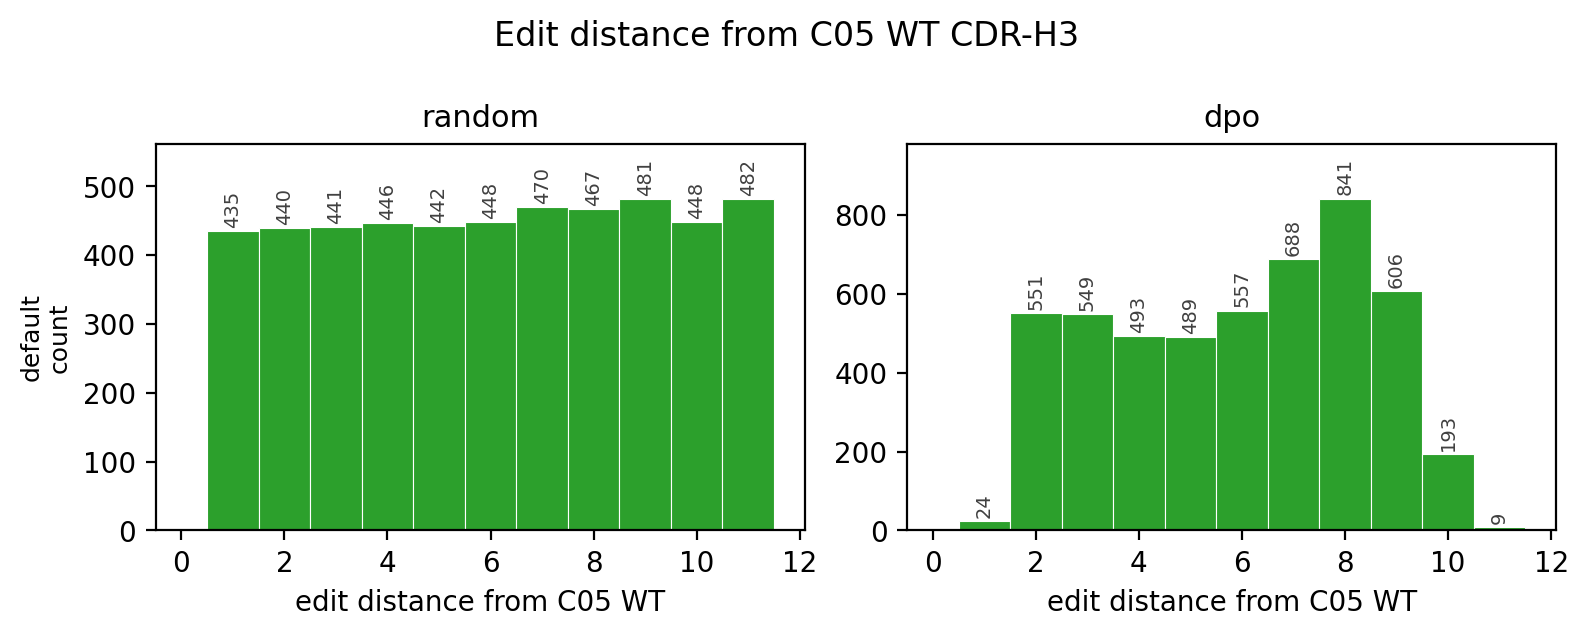

Saved PDF: /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m/comparison_pairwise_hamming.pdf


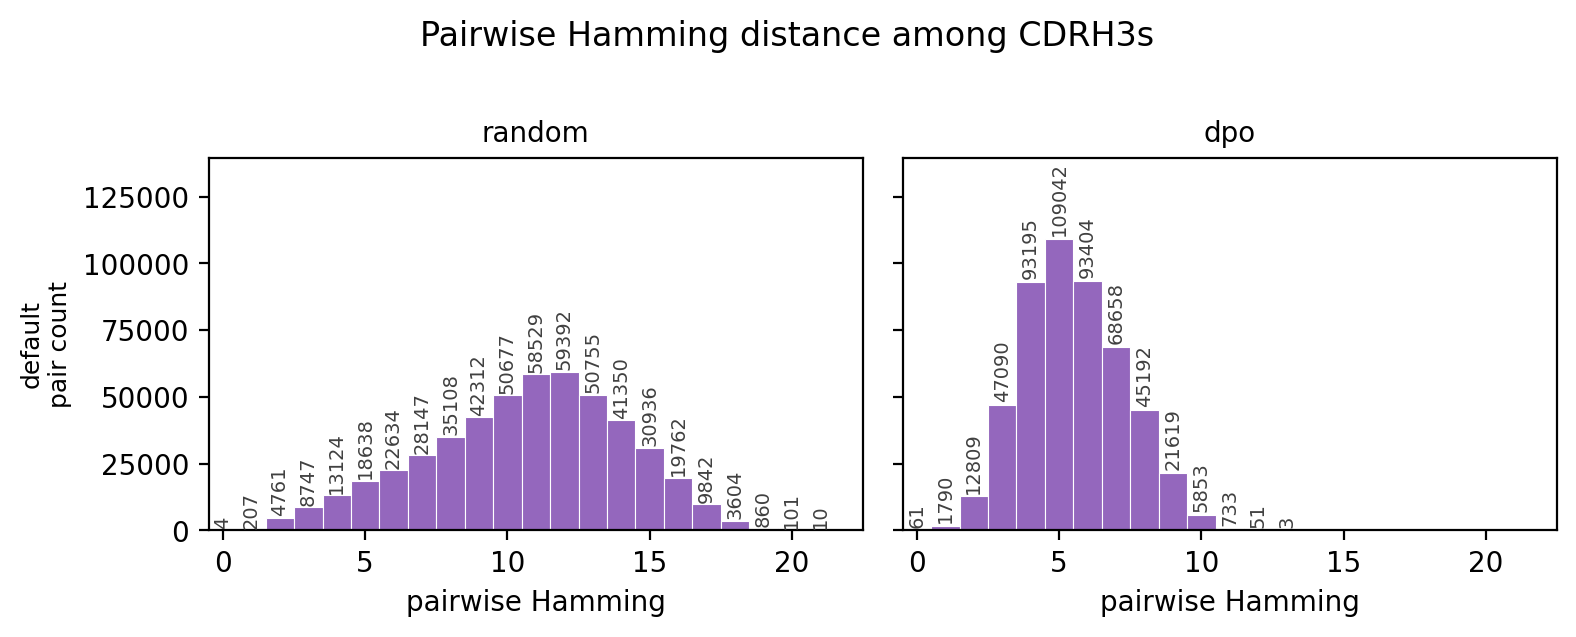

In [11]:
for stem in ['comparison_sequence_logo',
             'comparison_position_mutation_freq',
             'comparison_edit_distance',
             'comparison_pairwise_hamming']:
    print(f'Saved PDF: {FIG_DIR / (stem + ".pdf")}')
    display(Image(filename=str(FIG_DIR / (stem + '.png'))))

### Why trust_radius = 11 for the random baseline

These two summary figures come from the random-baseline trust-radius sweep
(`[2, 4, 6, 8, 11]`). For each radius the sampler's per-position amino-acid
frequency matrix (24 positions × 20 AAs) is compared to that of the `ed2_m22`
DMS reference.

**Entropy heatmap** (`random_entropy_heatmap`): rows = trust radius, columns =
the 24 CDR-H3 positions, colour = Shannon entropy of the sampled AA distribution
at that position. A larger trust radius lets each sequence mutate more positions,
so the rows get hotter (more varied per-position sampling); a small radius keeps
most positions fixed at the WT residue.

**JSD vs trust radius** (`random_jsd_vs_radius`) — two panels, both using the
Jensen–Shannon divergence (JSD, in bits, 0 = identical, 1 = maximally different)
between the sampler's and the DMS reference's per-position AA frequencies: the
left panel averages the JSD over the 24 positions vs the radius; the right draws
one line per position. Because the random sampler is uniform over observed
residues (not frequency-weighted), it never matches the DMS marginals as closely
as the PSSM does — the JSD stays higher and is driven mostly by the variable
positions.

We use **trust_radius = 11** because it matches the DPO beam-search budget
(`--n-steps 11`), so both generators are allowed the same maximum number of edits
from WT.

2026-09-18 17:39:41,413 INFO Wrote /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m/random_entropy_heatmap.pdf
2026-09-18 17:39:43,538 INFO Wrote /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m/random_entropy_heatmap.png


Saved PDF: /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m/random_entropy_heatmap.pdf


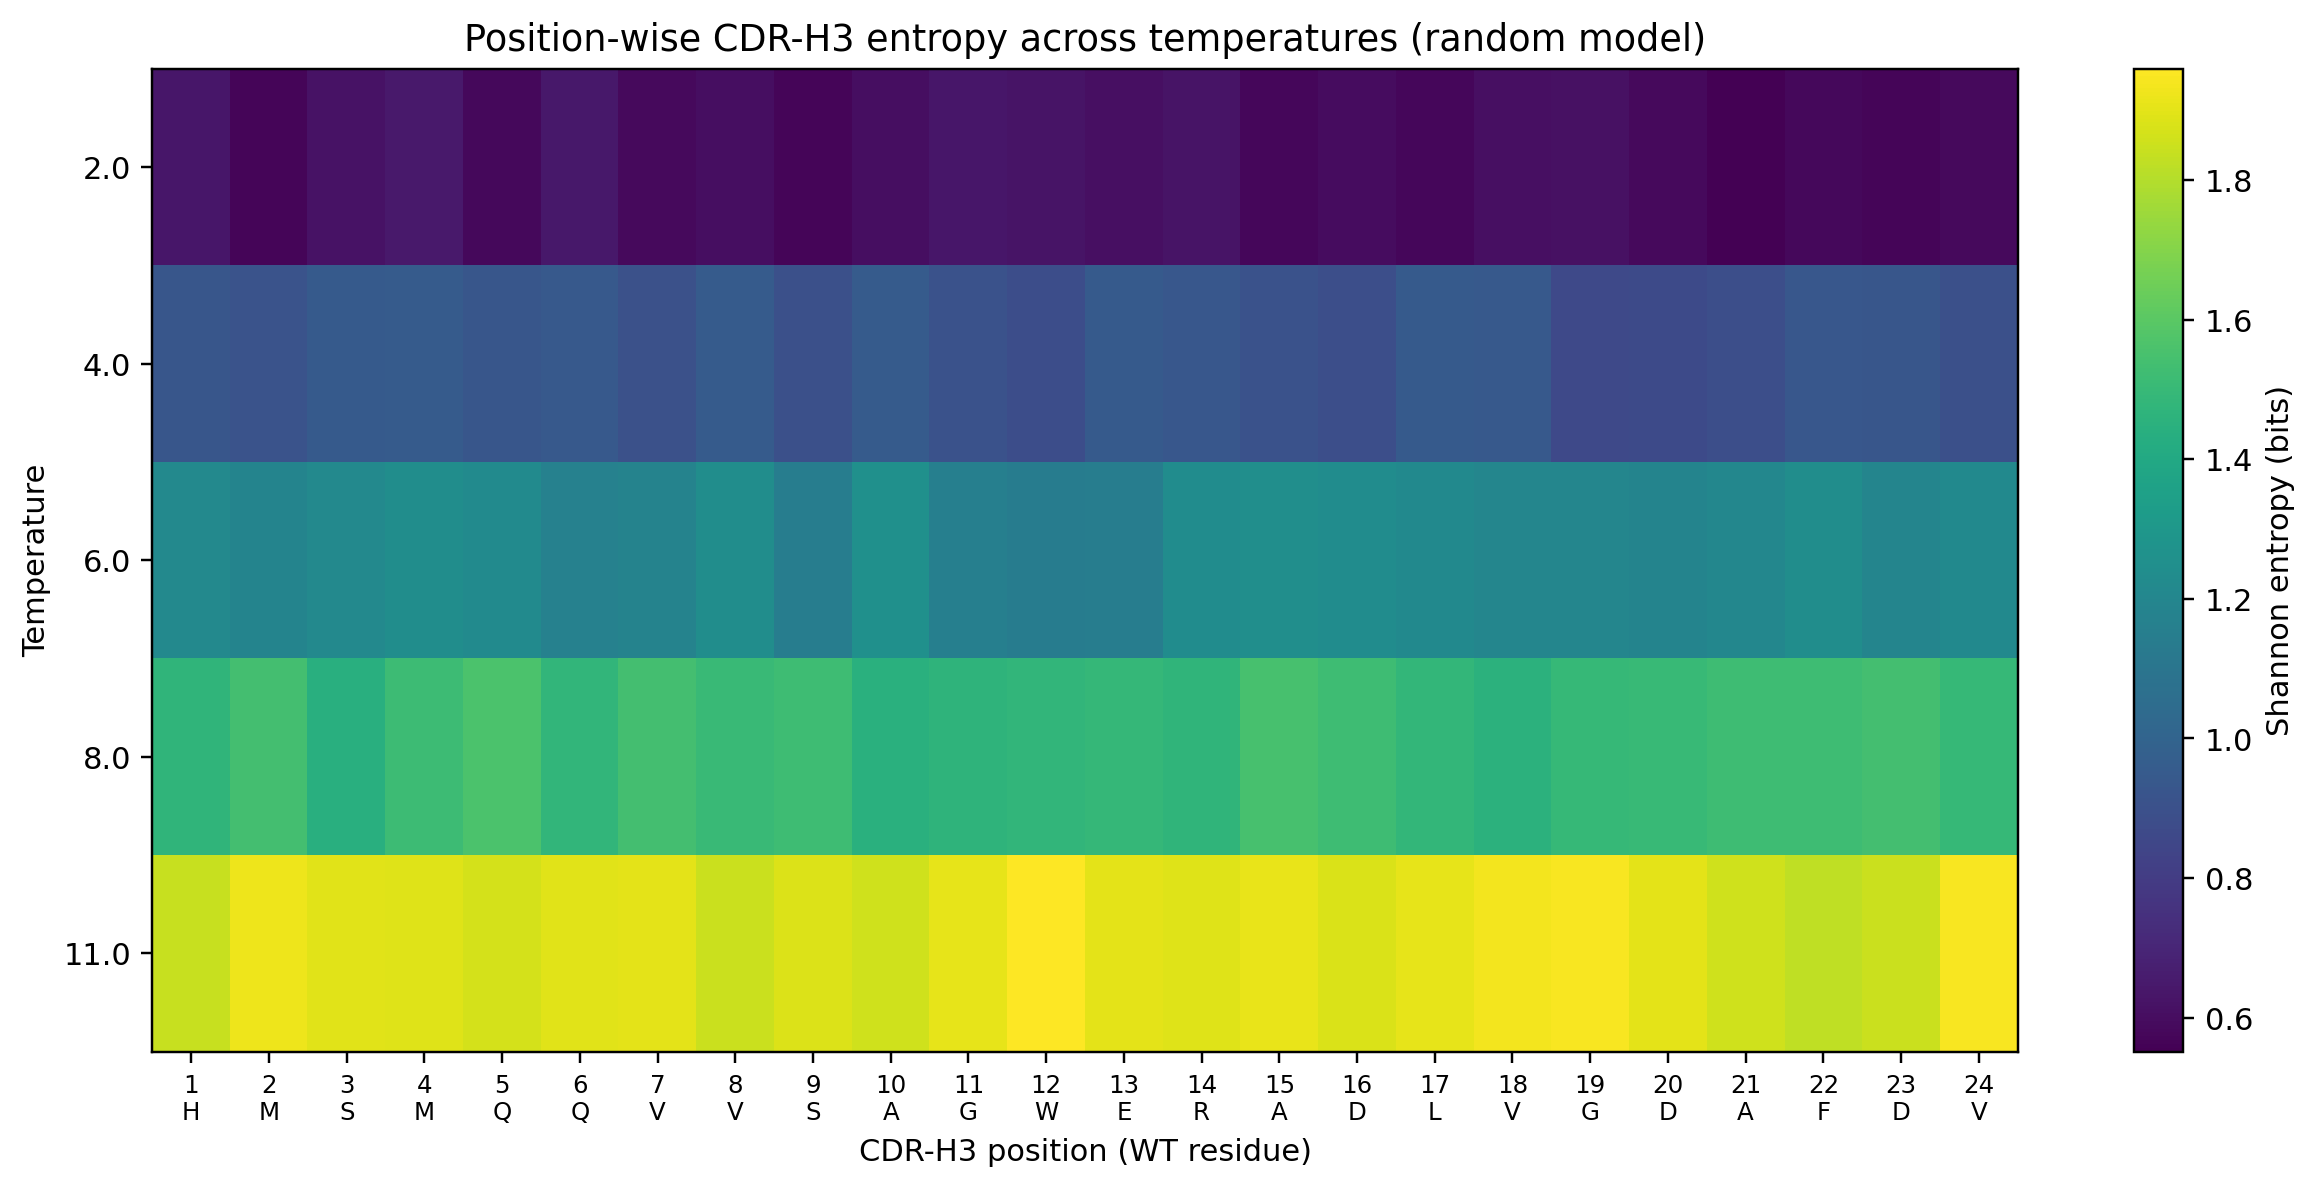

2026-09-18 17:39:46,218 INFO Wrote /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m/random_jsd_vs_radius.pdf
2026-09-18 17:39:48,759 INFO Wrote /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m/random_jsd_vs_radius.png


Saved PDF: /cluster/home/gguidarini/protein-design/report/figures/random_vs_dpo_650m/random_jsd_vs_radius.pdf


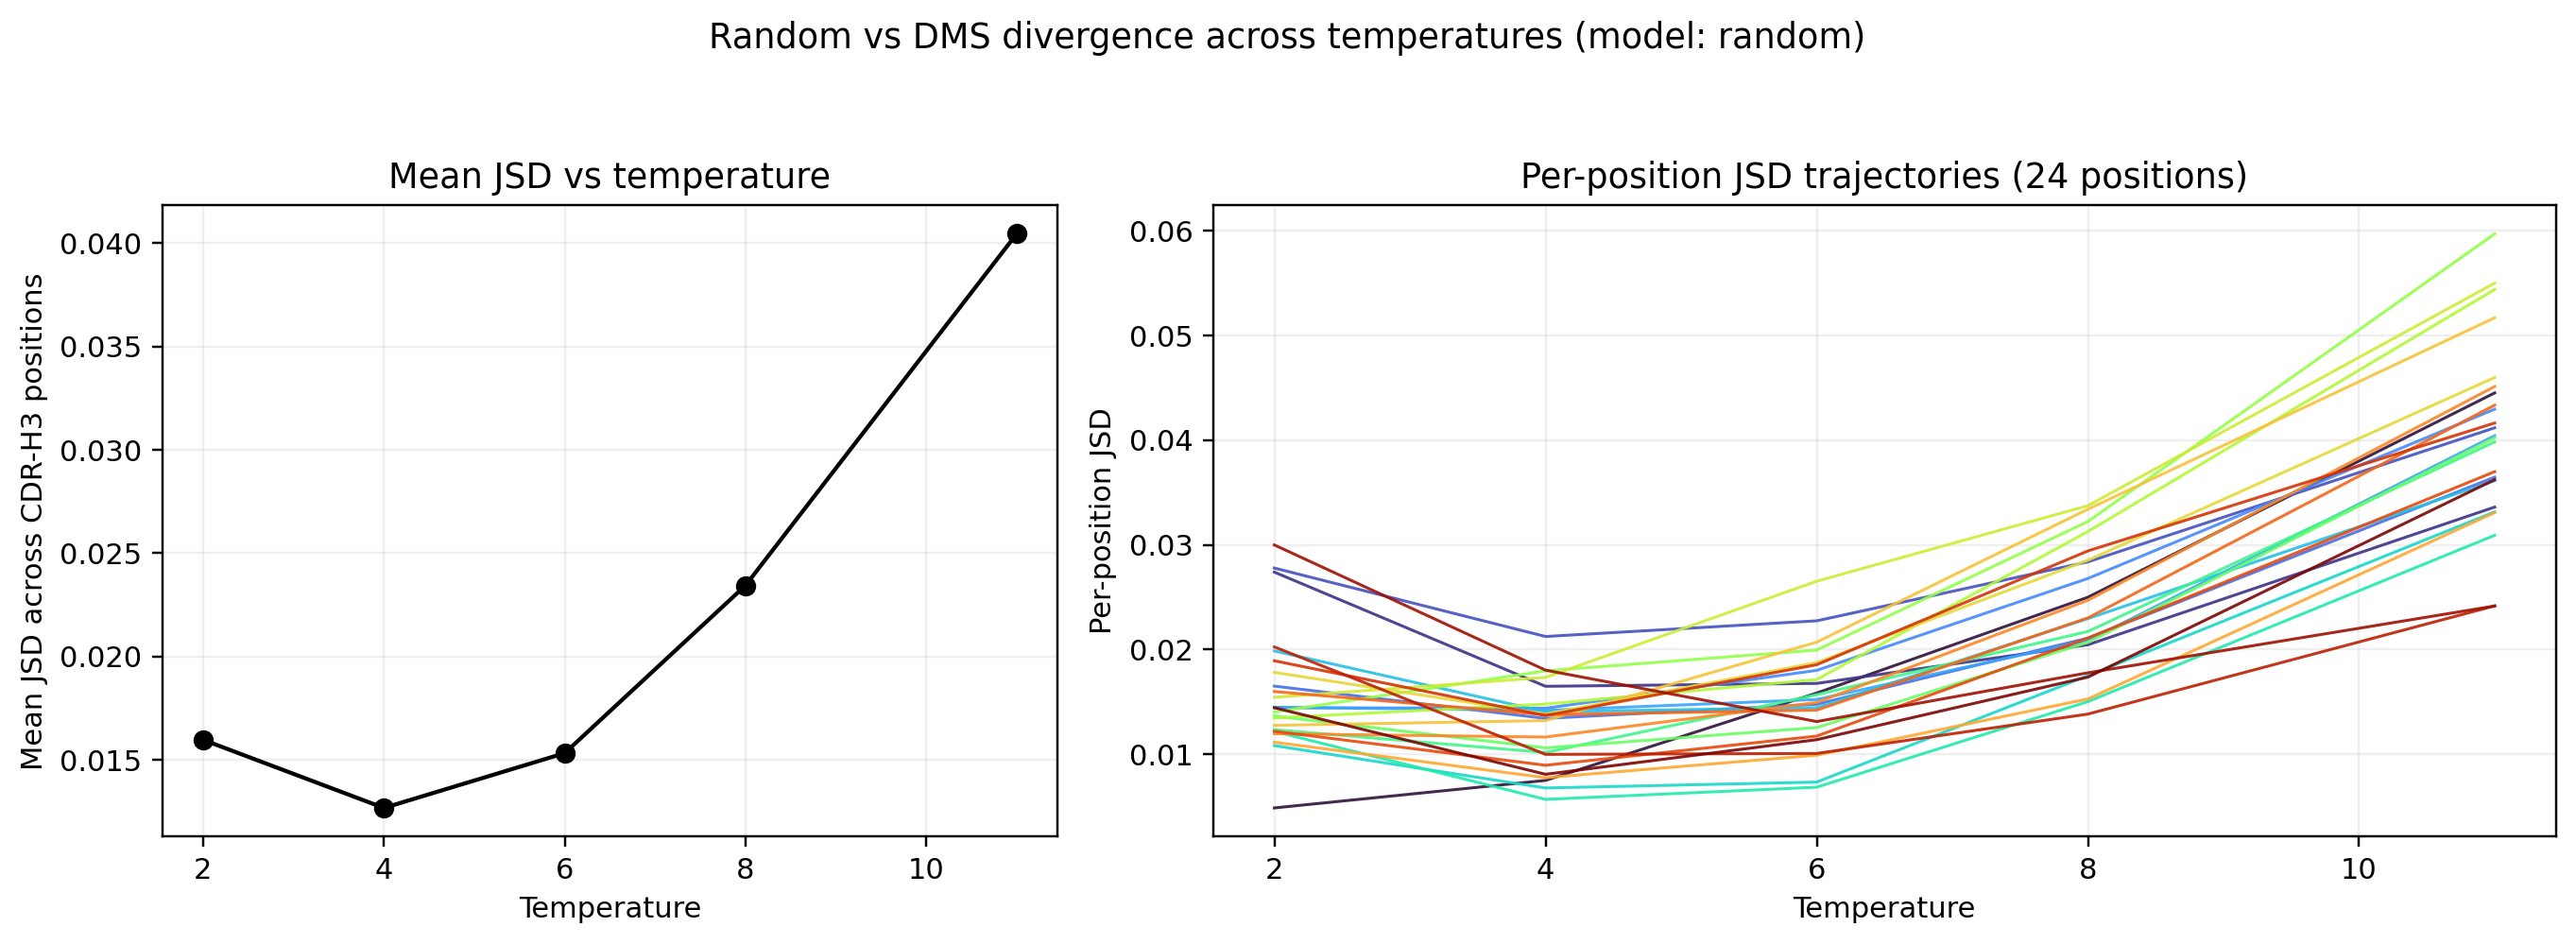

In [12]:
from protein_design.random_baseline import resolve_train_split_with_fallback

# DMS reference used by the JSD plot (same train split the sweep used).
dms_ref_path, _src = resolve_train_split_with_fallback(
    dataset_key='ed2_m22',
    dms_config_path='conf/data/dms/default.yaml',
    local_splits_dir='data/dms_splits',
)

# Per-trust-radius random-baseline CSVs produced by the sweep. NOTE: the shared
# plot scripts take a numeric sweep key per CSV (--temp-csv); we pass the trust
# radius as that key, so the figures' x-axis reads "temperature" but the values
# are radii (see the markdown above).
radius_csv_args = []
for csv in sorted(RANDOM_SWEEP_DIR.glob('radius_*/random_output.csv'),
                  key=lambda p: int(p.parent.name.replace('radius_', ''))):
    r = csv.parent.name.replace('radius_', '')
    radius_csv_args += ['--temp-csv', f'{r}={csv}']

def run_sweep_plot(script, extra, stem):
    """Run a sweep plot script once per format (pdf saved + png shown)."""
    base = ['uv', 'run', 'python', f'scripts/analysis/{script}', *radius_csv_args,
            '--model-variant', 'random', '--sampler-label', 'random',
            '--sweep-label', 'trust radius', *extra]
    for fmt in ('pdf', 'png'):
        subprocess.run(base + ['--output-name', f'{stem}.{fmt}', '--output-dir', str(FIG_DIR)],
                       check=True, cwd=REPO)
    print(f'Saved PDF: {FIG_DIR / (stem + ".pdf")}')
    display(Image(filename=str(FIG_DIR / (stem + '.png'))))

run_sweep_plot('plot_temp_entropy_heatmap.py', [], 'random_entropy_heatmap')
run_sweep_plot('plot_temp_jsd_vs_temp.py',
               ['--dms-m22', str(dms_ref_path), '--max-dms', '500'],
               'random_jsd_vs_radius')

## Scorer — main comparison (PGLD)

Load the PGLD scores for both generated sets and the reference `ed2_m22` test
split, merge them onto their sequence frames, and compare.

In [13]:
dpo_scores  = pd.read_csv(DPO_SCORES_CSV)    # columns: cdrh3, score
rand_scores = pd.read_csv(RANDOM_SCORES_CSV)   # columns: cdrh3, score
ref_scores  = pd.read_csv(REF_SCORE_CSV)     # columns: aa, score

dpo_m  = dpo_seqs.merge(dpo_scores,  on=GEN_SEQ_COL, how='inner')
rand_m = rand_seqs.merge(rand_scores, on=GEN_SEQ_COL, how='inner')
ref_m  = ref_scores.rename(columns={REF_SEQ_COL: GEN_SEQ_COL}).copy()

print(f'scored — DPO: {len(dpo_m)}, random baseline: {len(rand_m)}, reference ed2_m22 test: {len(ref_m)}')

# Reference threshold for "better than WT": the PGLD scorer's OWN prediction for
# the WT CDR-H3 (apples-to-apples with the predicted scores plotted here).
WT_SCORER = None
if WT_SCORE_CSV.exists():
    WT_SCORER = float(pd.read_csv(WT_SCORE_CSV)['score'].iloc[0])
    print(f'WT threshold (scorer-predicted) = {WT_SCORER:.3f}')
else:
    print(f'[note] scorer WT prediction not found at {WT_SCORE_CSV} '
          f'(run score_generated_with_esme.sbatch on a 1-row WT csv) — WT line/column omitted.')

# Okabe-Ito colourblind-safe palette, shared across all score figures.
MODEL_COLORS = {'Random (R=11)': COLORS['orange'], 'DPO 650M': COLORS['blue'],
                'ed2_m22 test (ref)': COLORS['green']}

FileNotFoundError: [Errno 2] No such file or directory: '/cluster/scratch/gguidarini/protein-design/pssm_vs_dpo_650m/scores/dpo_650m_step8250_filtered_m22.csv'

### PGLD score distributions

Random vs DPO vs the `ed2_m22` test split (all three are PGLD *scorer-predicted*
scores). The dashed line marks the scorer's prediction for the WT CDR-H3 —
sequences to its right are predicted better-than-WT binders.

In [14]:
series = {
    'Random (R=11)': rand_m['score'].to_numpy(),
    'DPO 650M': dpo_m['score'].to_numpy(),
}

def _wt_line(ax, vertical):
    """Draw the scorer-predicted WT line (skip if WT was not scored)."""
    if WT_SCORER is None:
        return
    line = ax.axvline if vertical else ax.axhline
    line(WT_SCORER, color='0.4', linestyle='--', linewidth=1.3, zorder=1,
         label='WT (scorer-predicted)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.3))

# Left: soft filled step histograms (light fill + crisp outline), shared palette.
for name, vals in series.items():
    c = MODEL_COLORS[name]
    ax1.hist(vals, bins=40, histtype='stepfilled', density=True,
             color=c, alpha=0.16, zorder=2)
    ax1.hist(vals, bins=40, histtype='step', density=True,
             color=c, linewidth=1.9, label=name, zorder=3)
_wt_line(ax1, vertical=True)
ax1.set_xlabel('predicted PGLD score'); ax1.set_ylabel('Density')
ax1.legend(fontsize=8, frameon=False)
ax1.set_title('PGLD score distribution', pad=20)
ax1.text(0.5, 1.005, 'density-normalized — area = 1 within each group',
         transform=ax1.transAxes, ha='center', va='bottom',
         fontsize=7, style='italic', color='0.4')
ax1.spines[['top', 'right']].set_visible(False)

# Right: violins, palette-coloured bodies with clean dark median/whisker lines.
names = list(series)
parts = ax2.violinplot([series[n] for n in names], showmedians=True, showextrema=True)
for pc, n in zip(parts['bodies'], names):
    pc.set_facecolor(MODEL_COLORS[n]); pc.set_edgecolor(MODEL_COLORS[n])
    pc.set_alpha(0.55); pc.set_linewidth(1.3)
for key in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    if key in parts:
        parts[key].set_color('0.35'); parts[key].set_linewidth(1.1)
if 'cmedians' in parts:
    parts['cmedians'].set_linewidth(2.0)
_wt_line(ax2, vertical=False)
ax2.set_xticks(range(1, len(names) + 1)); ax2.set_xticklabels(names, rotation=15, fontsize=8)
ax2.set_ylabel('PGLD score')
# matplotlib normalizes every violin to the same max width, so the widths are
# NOT comparable across groups (they do not reflect sample size) — flag this.
ax2.set_title('PGLD score — violin', pad=20)
ax2.text(0.5, 1.005, 'violins normalized to equal width — widths not to scale across groups',
         transform=ax2.transAxes, ha='center', va='bottom',
         fontsize=7, style='italic', color='0.4')
ax2.legend(fontsize=8, frameon=False)
ax2.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'm22_score_distributions')

NameError: name 'rand_m' is not defined

### Score vs distance from WT

Does one generator reach high PGLD scores while staying closer to (or further
from) the C05 WT? `n_mutations` is the Hamming distance of the CDR-H3 from WT.

In [15]:
# Median PGLD score per Hamming distance from WT, with an IQR band per model.
# No underlying scatter — just the trend + spread.
DIST_COLORS = {'Random (R=11)': COLORS['orange'],
               'DPO 650M':     COLORS['blue']}

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 3.0))
for name, dfm in [('Random (R=11)', rand_m), ('DPO 650M', dpo_m)]:
    color = DIST_COLORS[name]
    # median + IQR per integer Hamming distance, only bins with >=10 sequences
    stats = (dfm.groupby('n_mutations')['score']
             .agg(median='median', count='count',
                  q25=lambda s: s.quantile(0.25),
                  q75=lambda s: s.quantile(0.75)))
    stats = stats[stats['count'] >= 10]
    ax.fill_between(stats.index, stats['q25'], stats['q75'], color=color, alpha=0.20)
    ax.plot(stats.index, stats['median'], '-o', color=color, lw=2.4, ms=6,
            label=f'{name} — median (IQR band)')

if WT_SCORER is not None:
    ax.axhline(WT_SCORER, color='0.4', linestyle='--', linewidth=1.2,
               label='WT (scorer-predicted)')
ax.set_xlabel('n_mutations from C05 WT (Hamming)')
ax.set_ylabel('PGLD score')
ax.set_title('PGLD score vs distance from WT', pad=20)
ax.text(0.5, 1.005, 'line = median score per distance, band = IQR',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=7, style='italic', color='0.4')
ax.legend(fontsize=8)
fig.tight_layout()
save_show_fig(fig, 'm22_score_vs_distance')

NameError: name 'rand_m' is not defined

### Summary table

Mean / median predicted PGLD score, fraction above the scorer's WT prediction
(`frac_above_WT_scorer`), and N per model (and the reference split).

In [16]:
def score_summary(name, vals):
    vals = np.asarray(vals, dtype=float)
    row = {'set': name, 'n': len(vals),
           'mean_score': float(np.mean(vals)),
           'median_score': float(np.median(vals))}
    # frac above the scorer's OWN prediction for WT (apples-to-apples with these
    # predicted scores) — only if the WT was scored.
    if WT_SCORER is not None:
        row['frac_above_WT_scorer'] = float(np.mean(vals > WT_SCORER))
    return row

summary = pd.DataFrame([
    score_summary('Random (R=11)', rand_m['score']),
    score_summary('DPO 650M', dpo_m['score']),
    score_summary('ed2_m22 test (ref)', ref_m['score']),
])
if WT_SCORER is not None:
    print(f'Threshold — WT scorer-predicted = {WT_SCORER:.3f}')
display(summary.round(3))

NameError: name 'rand_m' is not defined

### Mean score of the top-k% of sequences

In practice you synthesise only the best few percent of a generated library, so the **elite tail** — not the bulk — is what decides whether a generator is useful. Each curve below is the mean predicted PGLD score of the top-k% of that library (ranked by the same score). The left (small-k) end is the most selective slice; `k = 100%` reproduces the full-set mean from the summary table above. A flat curve means the library has no usable tail above its bulk; a steeply rising tail (toward small k) means selection buys real score.

In [17]:
# Mean predicted PGLD score of the TOP-k% of each library, ranked by that same
# score. Isolates the elite tail you would actually pick: k=100% is the full-set
# mean (matches the summary table); small k is the high-scoring slice.
TOPK_GRID = np.geomspace(0.5, 100, 60)   # log-spaced %, resolves the elite tail


def topk_mean_curve(vals, grid):
    """Mean of the top-k% highest values, for each k% in grid."""
    v = np.sort(np.asarray(vals, dtype=float))[::-1]
    n = len(v)
    return np.asarray([v[: max(1, int(np.ceil(n * k / 100.0)))].mean() for k in grid])


topk_series = {
    'Random (R=11)':  rand_m['score'].to_numpy(),
    'DPO 650M': dpo_m['score'].to_numpy(),
}

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 3.0))
for name, vals in topk_series.items():
    ax.plot(TOPK_GRID, topk_mean_curve(vals, TOPK_GRID),
            color=MODEL_COLORS[name], lw=2.3, label=name, zorder=3)
if WT_SCORER is not None:
    ax.axhline(WT_SCORER, color='0.4', ls='--', lw=1.3,
               label='WT (scorer-predicted)', zorder=1)
ax.set_xscale('log')
ax.set_xlabel('top-k% of sequences kept (ranked by PGLD score)')
ax.set_ylabel('Mean PGLD')
ax.set_title('PGLD score vs selection stringency (top-k%)', pad=10)
ax.text(0.5, 1.005, 'left = most selective slice;  k = 100% = full-set mean',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=7, style='italic', color='0.4')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'm22_topk_mean_score')

# Compact table at a few representative selection cuts.
_topk_cuts = [1, 5, 10, 25, 100]
_topk_rows = []
for name, vals in topk_series.items():
    curve = topk_mean_curve(vals, _topk_cuts)
    _topk_rows.append({'set': name, **{f'top_{k}%': m for k, m in zip(_topk_cuts, curve)}})
display(pd.DataFrame(_topk_rows).round(3))

NameError: name 'rand_m' is not defined

### Mean PGLD score of the top-N sequences (absolute count)

Same selection view as the top-k% figure above, but the x-axis is the **absolute number of sequences kept** rather than a percentage.  This makes the comparison fair when the two libraries have different sizes: both curves start at N = 1 and each stops when all of its own sequences are exhausted, so the region where only the larger library still has a curve is shown naturally (rather than hidden by the percentage normalisation).

In [18]:
# Mean PGLD score of the top-N sequences (absolute count).
# Each curve runs from N=1 to its own library size; NaN beyond (not plotted).
_n_max_m = max(len(v) for v in topk_series.values())
TOPN_GRID = np.unique(np.round(np.geomspace(1, _n_max_m, 300)).astype(int))


def topn_mean_curve(vals, grid):
    """Mean of the top-n highest values. NaN where n > len(vals)."""
    v = np.sort(np.asarray(vals, dtype=float))[::-1]
    n_total = len(v)
    out = np.full(len(grid), np.nan)
    for i, n in enumerate(grid):
        if n <= n_total:
            out[i] = v[:n].mean()
    return out


fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 3.0))
for name, vals in topk_series.items():
    y = topn_mean_curve(vals, TOPN_GRID)
    ax.plot(TOPN_GRID, y, color=MODEL_COLORS[name], lw=2.3,
            label=f'{name}  (total n={len(vals):,})', zorder=3)
if WT_SCORER is not None:
    ax.axhline(WT_SCORER, color='0.4', ls='--', lw=1.3,
               label='WT (scorer-predicted)', zorder=1)
ax.set_xscale('log')
ax.set_xlabel('number of top sequences kept (ranked by PGLD score)')
ax.set_ylabel('Mean PGLD')
ax.set_title('PGLD score vs selection count (top-N absolute)', pad=10)
ax.text(0.5, 1.005,
        "left = N=1 (single best);  curve ends at its library size",
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=7, style='italic', color='0.4')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'm22_topn_mean_score')

_topn_cuts = [10, 50, 100, 500, 1000, 5000]
_topn_rows = []
for name, vals in topk_series.items():
    v = np.sort(np.asarray(vals, dtype=float))[::-1]
    row = {'set': name, 'n_total': len(vals)}
    for n in _topn_cuts:
        row[f'top_{n}'] = round(float(v[:n].mean()), 3) if n <= len(vals) else None
    _topn_rows.append(row)
display(pd.DataFrame(_topn_rows))

NameError: name 'topk_series' is not defined

### Mean score of the top-k% of sequences — per-model mutation cap

Same top-k% selection view as above, but with a **per-cell** cap on the number of mutations from the C05 WT, set independently for each model via `NUM_MAX_DPO` / `NUM_MAX_RAND`. `None` means no capping for that model; an integer keeps only that model's sequences with `n_mutations <= num_max`. This knob is local to this cell and does not touch the global `MAX_N_MUTATIONS`.


In [19]:
# Top-k% mean PGLD score, but with a PER-CELL max-mutation cap set independently
# per model. None = no cap; an int keeps only that model's sequences with
# n_mutations <= num_max. Independent of the global MAX_N_MUTATIONS.
NUM_MAX_DPO  = 5   # cap for DPO 650M      (e.g. 5, 8, ... or None for no cap)
NUM_MAX_RAND = 5   # cap for Random (R=11)

_caps_m = {'Random (R=11)': NUM_MAX_RAND, 'DPO 650M': NUM_MAX_DPO}


def _cap_scores(df, col, num_max):
    """Values of `col`, keeping only rows with n_mutations <= num_max (None = all)."""
    kept = df if num_max is None else df[df['n_mutations'] <= num_max]
    return kept[col].to_numpy()


def _cap_lbl(num_max):
    return 'all' if num_max is None else f'\u2264{num_max}'


topk_series_cap = {
    'Random (R=11)': _cap_scores(rand_m, 'score', NUM_MAX_RAND),
    'DPO 650M':     _cap_scores(dpo_m,  'score', NUM_MAX_DPO),
}

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 3.0))
for name, vals in topk_series_cap.items():
    ax.plot(TOPK_GRID, topk_mean_curve(vals, TOPK_GRID),
            color=MODEL_COLORS[name], lw=2.3,
            label=f'{name}  (n_mut {_cap_lbl(_caps_m[name])}, n={len(vals)})', zorder=3)
if WT_SCORER is not None:
    ax.axhline(WT_SCORER, color='0.4', ls='--', lw=1.3,
               label='WT (scorer-predicted)', zorder=1)
ax.set_xscale('log')
ax.set_xlabel('top-k% of sequences kept (ranked by PGLD score)')
ax.set_ylabel('Mean PGLD')
ax.set_title('PGLD score vs selection stringency (top-k%) \u2014 per-model mut cap', pad=10)
ax.text(0.5, 1.005, 'left = most selective slice;  k = 100% = full-set mean',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=7, style='italic', color='0.4')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'm22_topk_mean_score_mutcap')

# Compact table at a few representative selection cuts.
_topk_cuts_cap = [1, 5, 10, 25, 100]
_topk_rows_cap = []
for name, vals in topk_series_cap.items():
    curve = topk_mean_curve(vals, _topk_cuts_cap)
    _topk_rows_cap.append({'set': name, 'num_max': _cap_lbl(_caps_m[name]), 'n': len(vals),
                           **{f'top_{k}%': m for k, m in zip(_topk_cuts_cap, curve)}})
display(pd.DataFrame(_topk_rows_cap).round(3))


NameError: name 'rand_m' is not defined

### Top-15 sequences by PGLD score

Highest-scoring generated CDR-H3s per model, with their distance from WT and
whether they already appear in a DMS dataset.

In [20]:
def top_n(dfm, annot, name, n=15):
    merged = dfm.merge(
        annot[[GEN_SEQ_COL, 'present_in_existing_dataset', 'matching_datasets']],
        on=GEN_SEQ_COL, how='left',
    ).rename(columns={'present_in_existing_dataset': 'in_training_data',
                      'matching_datasets': 'training_splits'})
    top = merged.sort_values('score', ascending=False).head(n).reset_index(drop=True)
    top.insert(0, 'model', name)
    return top[['model', GEN_SEQ_COL, 'score', 'n_mutations',
                'in_training_data', 'training_splits']]

print('Top 15 — Random (R=11)')
display(top_n(rand_m, rand_annot, 'Random (R=11)').round(3))
print('Top 15 — DPO 650M')
display(top_n(dpo_m, dpo_annot, 'DPO 650M').round(3))

Top 15 — Random (R=11)


NameError: name 'rand_m' is not defined

### Are the generated designs in the PGLD scorer's own training data?

Same overlap check as for the UQ scorer, now against the **PGLD scorer's**
train / val / test splits (`M22_{train,val,test}.csv`). The esme scorer is a
single regressor, so there is no uncertainty decomposition here — only the
predicted PGLD score.

The picture is the opposite of the UQ scorer: overlap is **large**. A big share
of the random library-mutant baseline's designs are literally in the scorer's training set, so its
PGLD scores partly reflect memorised sequences; the DPO library is far more novel.
Reassuringly, in-train vs novel score distributions are similar (the esme
regressor generalises rather than just memorising), but the overlap is an
important caveat when reading the headline PGLD comparison.

In [21]:
# Overlap of the generated CDR-H3s with the PGLD scorer's train/val/test
# splits. CDR-H3 lives in column 'aa'; the three splits are disjoint.
M22_DATA_DIR = Path('/cluster/project/infk/krause/ssussex/flu/data')
_m22_split_map = {}
for _s in ('train', 'val', 'test'):
    for _seq in pd.read_csv(M22_DATA_DIR / f'M22_{_s}.csv', usecols=['aa'])['aa']:
        _m22_split_map[_seq] = _s

for _m in (rand_m, dpo_m):
    _m['scorer_split'] = _m[GEN_SEQ_COL].map(_m22_split_map).fillna('novel')

_m22_overlap = {'Random (R=11)': rand_m, 'DPO 650M': dpo_m}

# --- Summary table: in-train vs novel score ---
def _m22_overlap_summary(name, df):
    rows = []
    for grp, sub in [('in_train', df[df['scorer_split'] == 'train']),
                     ('novel',    df[df['scorer_split'] == 'novel'])]:
        rows.append({'model': name, 'group': grp, 'n': len(sub),
                     'mean_score': sub['score'].mean(), 'median_score': sub['score'].median()})
    return rows

m22_overlap_table = pd.DataFrame(
    [r for name, df in _m22_overlap.items() for r in _m22_overlap_summary(name, df)]
)
for name, df in _m22_overlap.items():
    n_in = int((df['scorer_split'] != 'novel').sum())
    n_tr = int((df['scorer_split'] == 'train').sum())
    print(f"{name}: {n_in}/{len(df)} in dataset ({n_tr} train) "
          f"-> {100 * (1 - n_in / len(df)):.1f}% novel")
display(m22_overlap_table.round(3))

# --- 2-panel figure: overlap counts | score (in-train vs novel) ---
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.4))

# Panel A: how many generated CDR-H3s fall in each scorer split.
ax = axes[0]
splits = ['train', 'test', 'val']
x = np.arange(len(splits)); w = 0.38
for i, (name, df) in enumerate(_m22_overlap.items()):
    counts = [int((df['scorer_split'] == s).sum()) for s in splits]
    bars = ax.bar(x + (i - 0.5) * w, counts, w, color=MODEL_COLORS[name],
                  label=name, edgecolor='0.2', lw=0.6)
    for r, c in zip(bars, counts):
        ax.text(r.get_x() + r.get_width() / 2, c + 5, str(c), ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'{s}\nsplit' for s in splits])
ax.set_ylabel('Split count')
ax.set_title('Overlap with PGLD scorer dataset', pad=10)
ax.legend(fontsize=8, frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

# Panel B: PGLD score, novel vs in-train (both large n -> violins).
ax = axes[1]; pos = 0; ticks = []; labs = []
for name, df in _m22_overlap.items():
    c = MODEL_COLORS[name]
    for grp, sub in [('novel', df[df['scorer_split'] == 'novel']),
                     ('in-train', df[df['scorer_split'] == 'train'])]:
        vals = sub['score'].to_numpy()
        if len(vals) >= 2:
            parts = ax.violinplot(vals, positions=[pos], widths=0.8,
                                  showmedians=True, showextrema=True)
            for b in parts['bodies']:
                b.set_facecolor(c); b.set_edgecolor(c); b.set_linewidth(1.3)
                b.set_alpha(0.55 if grp == 'in-train' else 0.28)
            for key in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
                if key in parts: parts[key].set_color('0.35'); parts[key].set_linewidth(1.1)
        ticks.append(pos); labs.append(f"{name.split()[0]}\n{grp}\n(n={len(vals)})"); pos += 1
    pos += 0.4
if WT_SCORER is not None:
    ax.axhline(WT_SCORER, color='0.4', ls='--', lw=1.2, label='WT (scorer-pred)')
    ax.legend(fontsize=8, frameon=False)
ax.set_xticks(ticks); ax.set_xticklabels(labs, fontsize=7.5)
ax.set_ylabel('PGLD score'); ax.set_title('Score: in-train vs novel', pad=10)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle("Generated CDR-H3s vs the PGLD scorer's training data: overlap and score",
             y=1.03, fontsize=13)
fig.tight_layout()
save_show_fig(fig, 'm22_training_overlap')

NameError: name 'rand_m' is not defined

## Does a smaller trust radius maximise the PGLD score?

The random baseline's `trust_radius = 11` was chosen to match the DPO beam's
edit budget — **not** to maximise the scorer. A natural question, the analogue of
the PSSM low-temperature probe: since a smaller radius keeps the sampler closer
to WT (fewer edits), does a **small trust radius** push the PGLD score up — at the
cost of diversity?

The sweep already generated **5000 sequences at every radius** (`[2, 4, 6, 8,
11]`); here we score them all with PGLD (one `score_generated_with_esme.sbatch`
job per radius CSV) and plot score vs radius.

**Weighting note.** Scores are computed once per *unique* sequence, then merged
back onto the full 5000-row sample, so duplicates are weighted by how often they
were drawn. This matters at small radius, where the sampler collapses onto a
handful of near-WT sequences — the "expected score if you sample at this radius"
is the duplicate-weighted mean, not the mean over unique sequences.

In [22]:
# Build a per-trust-radius summary: duplicate-weighted PGLD score, diversity, and
# distance from WT. Requires the sweep score CSVs (scores/random_R{r}_m22.csv).
def _radius_of(p):
    return int(p.parent.name.split('radius_')[1])

rows, per_radius_scores = [], {}
missing = []
for csv in sorted(RANDOM_SWEEP_DIR.glob('radius_*/random_output.csv'), key=_radius_of):
    r_label = csv.parent.name.split('radius_')[1]
    score_csv = SCORES_DIR / f'random_R{r_label}_m22.csv'
    if not score_csv.exists():
        missing.append((r_label, csv))
        continue
    samp = pd.read_csv(csv)                                  # 5000 rows (with dups)
    samp = apply_mut_cap(samp, f'random R={r_label}', verbose=False)
    sc = pd.read_csv(score_csv)                              # unique cdrh3 -> score
    merged = samp.merge(sc, on=GEN_SEQ_COL, how='inner')    # weighted by frequency
    if len(merged) == 0:
        continue                                            # nothing within the cap
    vals = merged['score'].to_numpy()
    per_radius_scores[int(r_label)] = vals
    row = {'trust_radius': int(r_label), 'n_samples': len(vals),
           'n_unique': int(samp[GEN_SEQ_COL].nunique()),
           'mean_score': float(np.mean(vals)),
           'median_score': float(np.median(vals)),
           'max_score': float(np.max(vals)),
           'median_n_mut': float(merged['n_mutations'].median())}
    if WT_SCORER is not None:
        row['frac_above_WT'] = float(np.mean(vals > WT_SCORER))
    rows.append(row)

if missing:
    print('[note] no PGLD score file yet for trust_radius = '
          f'{[m[0] for m in missing]} - score each radius CSV with:')
    for r_label, csv in missing:
        print(f'  sbatch bash_scripts/utils/score_generated_with_esme.sbatch '
              f'--input-csv {csv} '
              f'--output-csv {SCORES_DIR / ("random_R" + r_label + "_m22.csv")}')

radius_summary = pd.DataFrame(rows).sort_values('trust_radius').reset_index(drop=True)
display(radius_summary.round(3))
if len(radius_summary):
    best = radius_summary.loc[radius_summary['mean_score'].idxmax()]
    print(f"Best duplicate-weighted mean score at trust_radius = {int(best['trust_radius'])}: "
          f"mean = {best['mean_score']:.3f}  (n_unique = {int(best['n_unique'])}, "
          f"median edit-dist = {best['median_n_mut']:.0f})")
    if WT_SCORER is not None:
        print(f"For reference: DPO 650M mean = {dpo_m['score'].mean():.3f}, "
              f"WT (scorer) = {WT_SCORER:.3f}")

[note] no PGLD score file yet for trust_radius = ['2', '4', '6', '8', '11'] - score each radius CSV with:
  sbatch bash_scripts/utils/score_generated_with_esme.sbatch --input-csv /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/random_sweep/radius_2/random_output.csv --output-csv /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/scores/random_R2_m22.csv
  sbatch bash_scripts/utils/score_generated_with_esme.sbatch --input-csv /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/random_sweep/radius_4/random_output.csv --output-csv /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/scores/random_R4_m22.csv
  sbatch bash_scripts/utils/score_generated_with_esme.sbatch --input-csv /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/random_sweep/radius_6/random_output.csv --output-csv /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/scores/random_R6_m22.csv
  sbatch bash_scripts/utils/score_generated_with_esme.sbatch --input-

KeyError: 'trust_radius'

In [23]:
if len(radius_summary):
    R = radius_summary['trust_radius']
    # Okabe-Ito family: random-baseline stats in oranges, DPO blue, reference green.
    RAND_MEAN, RAND_MED, RAND_MAX = COLORS['orange'], '#A94700', '#B84D00'
    DPO_C, WT_C, GREEN_C = COLORS['blue'], '0.4', COLORS['green']
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.4))

    # Left: random-baseline score statistics vs trust radius, with WT and DPO refs.
    axA.plot(R, radius_summary['mean_score'], '-o', color=RAND_MEAN, lw=2.4, ms=6,
             label='random mean (dup-weighted)')
    axA.plot(R, radius_summary['median_score'], '--s', color=RAND_MED, lw=1.8, ms=5,
             label='random median')
    axA.plot(R, radius_summary['max_score'], ':^', color=RAND_MAX, lw=1.8, ms=6,
             label='random max')
    if WT_SCORER is not None:
        axA.axhline(WT_SCORER, color=WT_C, ls='--', lw=1.3, label='WT (scorer)')
    axA.axhline(dpo_m['score'].mean(), color=DPO_C, ls='-', lw=2.0, alpha=0.9,
                label='DPO 650M mean')
    best_r = radius_summary.loc[radius_summary['mean_score'].idxmax(), 'trust_radius']
    axA.axvline(best_r, color='0.6', ls=':', lw=1.2, alpha=0.7)
    axA.set_xlabel('random sampler trust radius (max edits from WT)')
    axA.set_ylabel('PGLD score')
    axA.set_title('PGLD score vs trust radius', pad=20)
    axA.text(0.5, 1.005, 'small radius stays near WT; large radius degrades quality',
             transform=axA.transAxes, ha='center', va='bottom',
             fontsize=7, style='italic', color='0.4')
    axA.legend(fontsize=7, frameon=False)
    axA.spines[['top', 'right']].set_visible(False)

    # Right: the diversity trade-off - fraction above WT (left y) and #unique (right y).
    if WT_SCORER is not None:
        axB.plot(R, radius_summary['frac_above_WT'], '-o', color=RAND_MEAN, lw=2.4, ms=6)
        axB.set_ylabel('Above WT', color=RAND_MEAN)
        axB.tick_params(axis='y', labelcolor=RAND_MEAN)
        axB.set_ylim(0, 1)
    axB2 = axB.twinx()
    axB2.plot(R, radius_summary['n_unique'], '-^', color=GREEN_C, lw=2.4, ms=6, alpha=0.9)
    axB2.set_ylabel('Unique', color=GREEN_C)
    axB2.tick_params(axis='y', labelcolor=GREEN_C)
    axB.set_xlabel('random sampler trust radius (max edits from WT)')
    axB.set_title('Score-vs-diversity trade-off', pad=20)
    axB.text(0.5, 1.005, 'quality (orange) and diversity (green) move in opposite directions',
             transform=axB.transAxes, ha='center', va='bottom',
             fontsize=7, style='italic', color='0.4')
    axB.spines[['top']].set_visible(False)
    axB2.spines[['top']].set_visible(False)
    fig.tight_layout()
    save_show_fig(fig, 'random_score_vs_trust_radius')
else:
    print('No per-radius scores available yet - skipping plot.')

NameError: name 'radius_summary' is not defined

**Result — the trust radius is a diversity / distance knob, not an affinity
knob.** The random library-mutant sampler is WT-centered: a *smaller* trust
radius makes fewer edits and therefore stays closer to the C05 **WT**, so its
duplicate-weighted mean PGLD score rises toward the WT score while the library
collapses onto a handful of near-WT sequences; a *larger* radius buys diversity
and distance from WT at the cost of average predicted score. (Read the exact
numbers off the table and figure above.)

This is the direct analogue of the PSSM temperature story: "the radius that
maximises the score" is essentially "the one that stays closest to WT", because
the random sampler only recombines residues already observed near the consensus
and is blind to epistasis. Shrinking the radius does not *discover*
better-than-WT designs; it regresses toward WT, and as soon as a larger radius
buys real diversity and distance the score falls off — the independent-positions
/ no-epistasis limitation, now seen as a function of the trust radius.

**Takeaway:** there is no trust radius at which uniform, per-position,
over-observed-residues sampling produces a *population* that both beats WT on
average and genuinely explores sequence space. High score **and** diversity
**and** distance from WT at once requires the coupled model (DPO).

## Quality vs diversity — the fair comparison

A library that barely moves from WT trivially scores high (we just saw the random
baseline "win" at small radius only by regressing toward WT), so comparing the
two generators at *their own* diversities is unfair. Instead we control for
diversity directly.

- **x-axis = diversity** of the generated library, measured two ways for
  robustness:
  - **total per-position entropy** — sum over the 24 positions of the Shannon
    entropy of the amino-acid distribution at that position (bits): how varied
    each column is, on its own;
  - **mean pairwise Hamming distance** — the expected number of positions at
    which two randomly drawn sequences differ, computed exactly from the same
    per-position frequencies as $\sum_p (1 - \sum_a f_{p,a}^2)$.

  Both use the full 5000-sequence sample (duplicates kept), so a small trust
  radius that collapses onto a few sequences correctly reads as low diversity.
- **y-axis = quality** = duplicate-weighted mean predicted PGLD score.

The **random baseline** traces a curve — one point per trust radius — its
quality-vs-diversity frontier (we expect it to fall: more diversity → lower
average quality). **DPO** is a single point. If the DPO point sits **above** the
random-baseline curve at the same x — and ideally everywhere — then at matched
diversity the PLM produces higher-scoring sequences, which is the claim we want
to establish.

In [24]:
# Diversity of a library = computed on the full 5000-sequence sample (dups kept).
def library_diversity(seqs):
    """(total per-position Shannon entropy [bits], mean pairwise Hamming dist)."""
    if not seqs:
        return 0.0, 0.0
    arr = np.array([list(s) for s in seqs])            # (N, L)
    H = PH = 0.0
    for p in range(arr.shape[1]):
        _, counts = np.unique(arr[:, p], return_counts=True)
        f = counts / counts.sum()
        H  += float(-(f * np.log2(f)).sum())           # Shannon entropy at pos p
        PH += float(1.0 - (f ** 2).sum())              # P(two draws differ at p)
    return H, PH

# random baseline: one library per trust radius (only radii with a score file).
div_rows = []
for csv in sorted(RANDOM_SWEEP_DIR.glob('radius_*/random_output.csv'), key=_radius_of):
    r = _radius_of(csv)
    if r not in set(radius_summary['trust_radius']):
        continue
    seqs_r = apply_mut_cap(pd.read_csv(csv), f'random R={r}', verbose=False)
    seqs_r = keep_novel(seqs_r)                                # NOVEL_ONLY: drop training-data overlaps
    H, PH = library_diversity(seqs_r[GEN_SEQ_COL].astype(str).tolist())
    q = float(radius_summary.loc[radius_summary['trust_radius'] == r, 'mean_score'].iloc[0])
    div_rows.append({'trust_radius': r, 'entropy_bits': H, 'pairwise_hamming': PH,
                     'mean_score': q})
rand_div = pd.DataFrame(div_rows).sort_values('entropy_bits').reset_index(drop=True)

# DPO: single library (novel-only when NOVEL_ONLY), duplicate-weighted quality.
_dpo_df = keep_novel(dpo_df)
dpo_H, dpo_PH = library_diversity(_dpo_df[GEN_SEQ_COL].astype(str).tolist())
dpo_q = float(_dpo_df.merge(dpo_scores, on=GEN_SEQ_COL, how='inner')['score'].mean())

display(rand_div.round(3))
print(f'DPO 650M: entropy = {dpo_H:.2f} bits, pairwise Hamming = {dpo_PH:.2f}, '
      f'mean score = {dpo_q:.3f}')

# "At matched diversity" read-off: nearest random trust radius in each metric.
for metric, dval in [('entropy_bits', dpo_H), ('pairwise_hamming', dpo_PH)]:
    i = (rand_div[metric] - dval).abs().idxmin()
    m = rand_div.loc[i]
    print(f"  matched {metric} (~{dval:.1f}): nearest random trust_radius={int(m['trust_radius'])} "
          f"-> mean {m['mean_score']:.2f}   vs   DPO {dpo_q:.2f}  "
          f"(gap {dpo_q - m['mean_score']:+.2f})")

NameError: name 'radius_summary' is not defined

In [25]:
# Styled quality-vs-diversity frontier: random-baseline curve (colour = trust
# radius) with the single DPO point overlaid, under two diversity metrics. Radius
# labels are auto-placed with adjustText (repelled, with short leader lines).
from adjustText import adjust_text

DPO_C, WT_C, LINE_C = COLORS['blue'], '0.35', '0.75'
cmap = plt.cm.viridis
rmin, rmax = rand_div['trust_radius'].min(), rand_div['trust_radius'].max()

fig, (axA, axB) = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.5))
panels = [(axA, 'entropy_bits', 'total per-position entropy (bits)', dpo_H,
           'Diversity = per-position entropy'),
          (axB, 'pairwise_hamming', 'mean pairwise Hamming distance', dpo_PH,
           'Diversity = mean pairwise Hamming')]
sc_last = None
for ax, xcol, xlab, dval, title in panels:
    d = rand_div.sort_values(xcol).reset_index(drop=True)
    ax.plot(d[xcol], d['mean_score'], '-', color=LINE_C, lw=2.0, zorder=2)
    sc_last = ax.scatter(d[xcol], d['mean_score'], c=d['trust_radius'], cmap=cmap,
                         vmin=rmin, vmax=rmax, s=130, edgecolor='white',
                         linewidth=1.4, zorder=3)
    ax.scatter([dval], [dpo_q], marker='*', s=680, color=DPO_C, edgecolor='black',
               linewidth=1.1, zorder=6)
    ax.annotate('DPO 650M', (dval, dpo_q), fontsize=12.5, fontweight='bold',
                color=DPO_C, xytext=(16, 2), textcoords='offset points', va='center')
    ax.axvline(dval, color=DPO_C, ls=':', lw=1.2, alpha=0.6)
    if WT_SCORER is not None:
        ax.axhline(WT_SCORER, color=WT_C, ls='--', lw=1.3, alpha=0.85)
        ax.annotate('WT', (ax.get_xlim()[1], WT_SCORER), fontsize=10, color=WT_C,
                    xytext=(-4, 4), textcoords='offset points', ha='right', va='bottom')

    # one label per trust-radius point.
    pts = [(r[xcol], r['mean_score'], f"R={int(r['trust_radius'])}")
           for _, r in d.iterrows()]
    texts = [ax.text(x, y, lab, fontsize=11, fontweight='bold', color='#1f1f1f',
                     ha='center', va='center',
                     bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.8))
             for x, y, lab in pts]
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle='-', color='#888888', lw=0.8),
                expand=(1.5, 2.0), force_text=(0.6, 1.0),
                only_move={'static': 'xy', 'text': 'xy', 'explode': 'xy'})

    ax.set_xlabel(xlab)
    ax.set_ylabel('Mean PGLD')
    ax.set_title(title, fontsize=12.5, pad=12)
    ax.grid(True, alpha=0.22, zorder=0)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)

fig.suptitle('Quality vs diversity — PGLD scorer\n'
             'Random-baseline frontier (one point per trust radius) vs the single DPO 650M point',
             y=1.04, fontsize=14)
cbar = fig.colorbar(sc_last, ax=[axA, axB], fraction=0.035, pad=0.02)
cbar.set_label('random sampler trust radius', fontsize=11)
save_show_fig(fig, 'random_dpo_quality_vs_diversity')

NameError: name 'rand_div' is not defined

**Result — the PLM dominates the baseline's diversity frontier.** Reading the
DPO star against the grey random-baseline curve (one point per trust radius):

- **At matched diversity, DPO wins.** The DPO library's entropy / mean pairwise
  Hamming pick out a trust radius with comparable diversity; at that *same*
  diversity the random baseline's duplicate-weighted mean score sits well below
  DPO's (see the matched-radius read-off printed above).
- **DPO beats the baseline across the whole frontier.** The random-baseline curve
  only approaches WT-level quality by collapsing to near-zero diversity (small
  radius ≈ staying at WT); DPO holds substantial diversity *and* a higher score,
  so its point sits above the entire curve.
- **This is the epistasis gap, made fair.** With diversity explicitly equalised
  the naive per-position / uniform-over-observed sampler still loses, because it
  stacks individually-plausible edits that are jointly poor; the PLM samples
  coordinated (epistatic) edits and reaches higher quality **and** diversity
  **and** distance from WT at once.

This is the cleanest statement of the comparison: **at equal library diversity,
the language model's designs are scored markedly higher than the naive
random-recombination baseline's.**

## Discussion

All "scores" below are **PGLD-scorer predictions** (in scorer units), not
experimental measurements. The reference threshold is the scorer's own
prediction for the WT CDR-H3 (printed above as `WT_SCORER`); the experimental WT
enrichment is a different scale and is not used here. The exact figures are in
the summary tables above — this section reads the qualitative pattern.

### 1. The scorer prefers DPO
DPO puts essentially its **entire** output above the scorer's WT prediction,
versus a much smaller fraction for the random library-mutant baseline and only a
few percent of the natural (unselected) `ed2_m22` test set. The random baseline
does clear a low bar — by recombining residues observed in good binders it beats
random natural variants — but it does not, on average, push past WT the way DPO
does.

### 2. The two generators explore sequence space very differently
- **The random baseline stays local and undirected:** it is WT-centered and
  spreads its edits thinly and uniformly across the loop (no learned hotspots),
  using only residues already observed at each position.
- **DPO moves further and edits decisively:** a larger median edit distance with
  mutations **concentrated** on a few learned hotspot positions, leaving the rest
  at WT. It has learned which positions matter and commits to them.

### 3. The decisive difference is *score vs distance* (epistasis)
As sequences move away from WT the random baseline's score **degrades sharply** —
its extra mutations are on average **deleterious**, because uniform per-position
sampling stacks individually-plausible changes that are jointly bad (no
epistasis) — while **DPO holds or improves** its score, evidence that it captures
the couplings the baseline is blind to. This is the concrete payoff of
"modelling + search" over "uniform per-position recombination".

### 4. DPO is also more novel — it is not just memorising
A larger fraction of DPO's unique sequences are absent from every DMS dataset
than the random baseline's (which, sampling near WT from observed residues,
frequently re-derives already-seen low-distance variants), and DPO's top hits are
largely **novel** rather than recombinations of known sequences.

### Caveats
- **Scorer, not assay.** Everything rests on the PGLD in-silico oracle. DPO and
  the scorer were trained on related data, so there is a real risk of
  **correlated optimism** — the model may be exploiting the scorer's blind spots.
  The headline numbers are a hypothesis to be **validated experimentally**, not a
  measured affinity.
- **Reference role.** The `ed2_m22` test split scores low by design — it is the
  full *unselected* DMS, dominated by poor binders. It anchors the scale; it is
  not a competing generator.
- **Unequal N / duplicates.** The random baseline yields fewer *unique* sequences
  than its 5000-row sample because near-WT sampling collides on duplicates;
  distributions are comparable but the counts differ.
- **Bounded search.** Beam search here is `B = 500`, `N = 11`, `T = 0.9`, seed 42;
  the random baseline is `trust_radius = 11`, seed 42. Both reachable spaces (and
  the score-vs-distance trends) may shift with different settings.

### Bottom line
The random library-mutant baseline establishes that uniformly recombining the
residues observed in good binders keeps you **near WT and modestly above the
natural distribution**, but cannot venture far without losing predicted affinity.
**DPO 650M + beam search produces sequences the scorer rates far higher, further
from WT, and largely novel** — consistent with a model that has learned
coordinated, epistatic edits rather than independent position preferences. The
clear next step is **experimental validation of the top DPO candidates**, since
the entire comparison is scorer-based.

## Second scorer — ModelArcEnsemble uncertainty scorer (Lorenz)

A second, independent opinion on the generated designs, from Lorenz Kaiser's
**uncertainty scorer** (`uncertainty_protein`, branch `Lorenz`). Where the PGLD scorer is a single ESM2-based regressor, this is a **6-member
heterogeneous deep ensemble** (3 MLPs + 3 CNNs) trained on the
`Chen-2026 / C05_M22_ED5` DMS with a one-hot encoding of the 24-residue CDR-H3.
Each member outputs a (mean, log-std) pair, so the ensemble returns not just a
point prediction but an **uncertainty decomposition**:

- **`pred`** — ensemble-mean predicted `binding_enrichment_adj` (the "score",
  analogous to the PGLD score but on this scorer's own scale).
- **`epistd`** — *epistemic* std: disagreement **between** the 6 members. High =
  the models extrapolate / haven't seen this region of sequence space → low
  confidence. This is the interesting one for novel designs.
- **`alestd`** — *aleatoric* std: the mean of each member's predicted noise →
  irreducible / data noise.
- **`totalstd`** = √(epistd² + alestd²).

Scoring runs through `scripts/analysis/score_sequences_with_uncertainty.py`,
which adapts our `cdrh3` CSVs to the scorer's schema, runs its `evaluate.py` in a
dedicated venv (`~/uncertainty_protein/.venv`, CPU), and writes a tidy
`cdrh3,pred,epistd,alestd,totalstd` CSV. As before, the notebook only preflights


### Preflight — uncertainty-scorer artifacts

Same pattern as the PGLD preflight: the UQ score CSVs for the two generated sets.


In [26]:
# Uncertainty scorer (Lorenz / ModelArcEnsemble one-hot) score CSVs.
DPO_UQ_CSV    = DPO_SCRATCH / 'scores' / 'dpo_650m_step8250_filtered_uq.csv'   # reused
DPO_UQ_CSV = tag_dpo_path(DPO_UQ_CSV)
RANDOM_UQ_CSV = SCORES_DIR / 'random_R11_uq.csv'
WT_UQ_CSV     = DPO_SCRATCH / 'scores' / 'wt_uq.csv'                           # reused

uq_ok = [
    check_artifact(
        DPO_UQ_CSV,
        'UQ scores - DPO filtered set (reused)',
        f'sbatch bash_scripts/utils/score_generated_with_uncertainty.sbatch '
        f'--input-csv {BEAM_DPO_FILTERED} --output-csv {DPO_UQ_CSV}',
    ),
    check_artifact(
        RANDOM_UQ_CSV,
        'UQ scores - random R=11 set',
        f'sbatch bash_scripts/utils/score_generated_with_uncertainty.sbatch '
        f'--input-csv {RANDOM_R11_CSV} --output-csv {RANDOM_UQ_CSV}',
    ),
]
if not all(uq_ok):
    raise FileNotFoundError(
        'Missing UQ score artifact(s) above - submit the printed sbatch job(s), '
        'then re-run this notebook.'
    )
print('All UQ score artifacts present.')

[MISSING] UQ scores - DPO filtered set (reused)
          /cluster/scratch/gguidarini/protein-design/pssm_vs_dpo_650m/scores/dpo_650m_step8250_filtered_uq.csv
          -> generate with:
             sbatch bash_scripts/utils/score_generated_with_uncertainty.sbatch --input-csv /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/beam_dpo/beam_dpo_650m_step8250_filtered.csv --output-csv /cluster/scratch/gguidarini/protein-design/pssm_vs_dpo_650m/scores/dpo_650m_step8250_filtered_uq.csv

[MISSING] UQ scores - random R=11 set
          /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/scores/random_R11_uq.csv
          -> generate with:
             sbatch bash_scripts/utils/score_generated_with_uncertainty.sbatch --input-csv /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/random_sweep/radius_11/random_output.csv --output-csv /cluster/scratch/gguidarini/protein-design/random_vs_dpo_650m/scores/random_R11_uq.csv



FileNotFoundError: Missing UQ score artifact(s) above - submit the printed sbatch job(s), then re-run this notebook.

In [27]:
dpo_uq  = pd.read_csv(DPO_UQ_CSV)    # columns: cdrh3, pred, epistd, alestd, totalstd
rand_uq = pd.read_csv(RANDOM_UQ_CSV)

dpo_u  = dpo_seqs.merge(dpo_uq,  on=GEN_SEQ_COL, how='inner')
rand_u = rand_seqs.merge(rand_uq, on=GEN_SEQ_COL, how='inner')
print(f'UQ-scored — DPO: {len(dpo_u)}, random baseline: {len(rand_u)}')

# Scorer's own prediction for WT (threshold for "better than WT", apples-to-apples).
WT_UQ = None
if WT_UQ_CSV.exists():
    WT_UQ = float(pd.read_csv(WT_UQ_CSV)['pred'].iloc[0])
    print(f'WT predicted (UQ scorer)  = {WT_UQ:.3f}')
else:
    print(f'[note] UQ WT prediction not found at {WT_UQ_CSV} — WT line omitted.')

FileNotFoundError: [Errno 2] No such file or directory: '/cluster/scratch/gguidarini/protein-design/pssm_vs_dpo_650m/scores/dpo_650m_step8250_filtered_uq.csv'

### UQ predicted-score distributions

DPO vs random baseline under the ensemble scorer (its own scale, *not* comparable to the
PGLD scorer). Set `UQ_DIST_MAX_MUT` to restrict this figure (and its summary
table) to designs within a given Hamming distance of WT; `None` keeps all designs.
The summary table reports the chosen `max_mutations` cut alongside the usual stats.


In [28]:
# Max #mutations from WT to include in THIS figure + its summary table.
# Set to None to include all designs (no distance cap); edit independently of the
# other cells.
UQ_DIST_MAX_MUT = 5   # e.g. 8 to keep only designs within 8 edits of WT

def _apply_uq_maxmut(df):
    if UQ_DIST_MAX_MUT is None:
        return df
    return df[df['n_mutations'] <= UQ_DIST_MAX_MUT]

rand_uf = _apply_uq_maxmut(rand_u)
dpo_uf  = _apply_uq_maxmut(dpo_u)
cap_str = 'all' if UQ_DIST_MAX_MUT is None else f'\u2264{UQ_DIST_MAX_MUT}'

series_u = {
    'Random (R=11)': rand_uf['pred'].to_numpy(),
    'DPO 650M':     dpo_uf['pred'].to_numpy(),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.3))
for name, vals in series_u.items():
    c = MODEL_COLORS[name]
    ax1.hist(vals, bins=40, histtype='stepfilled', density=True, color=c, alpha=0.16, zorder=2)
    ax1.hist(vals, bins=40, histtype='step', density=True, color=c, linewidth=1.9, label=name, zorder=3)
if WT_UQ is not None:
    ax1.axvline(WT_UQ, color='0.4', linestyle='--', linewidth=1.3, label='WT (scorer-predicted)')
ax1.set_xlabel('predicted score (UQ scorer)'); ax1.set_ylabel('Density')
ax1.legend(fontsize=8, frameon=False)
ax1.set_title(f'UQ predicted-score distribution (mut {cap_str})', pad=10)
ax1.spines[['top', 'right']].set_visible(False)

names = list(series_u)
parts = ax2.violinplot([series_u[n] for n in names], showmedians=True, showextrema=True)
for pc, n in zip(parts['bodies'], names):
    pc.set_facecolor(MODEL_COLORS[n]); pc.set_edgecolor(MODEL_COLORS[n]); pc.set_alpha(0.55); pc.set_linewidth(1.3)
for key in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    if key in parts: parts[key].set_color('0.35'); parts[key].set_linewidth(1.1)
if WT_UQ is not None:
    ax2.axhline(WT_UQ, color='0.4', linestyle='--', linewidth=1.3)
ax2.set_xticks(range(1, len(names) + 1)); ax2.set_xticklabels(names, fontsize=9)
ax2.set_ylabel('UQ score')
ax2.set_title(f'UQ predicted score (mut {cap_str})', pad=10)
fig.tight_layout()
save_show_fig(fig, 'uq_score_distributions')

# Summary table for THIS max-mutations cut (includes the max_mutations column).
def _uq_dist_summary(name, df):
    row = {'set': name,
           'max_mutations': ('all' if UQ_DIST_MAX_MUT is None else UQ_DIST_MAX_MUT),
           'n': len(df),
           'mean_pred': float(df['pred'].mean()),
           'median_pred': float(df['pred'].median()),
           'mean_epistd': float(df['epistd'].mean()),
           'mean_alestd': float(df['alestd'].mean()),
           'mean_totalstd': float(df['totalstd'].mean())}
    if WT_UQ is not None:
        row['frac_above_WT'] = float((df['pred'] > WT_UQ).mean())
    return row

uq_dist_table = pd.DataFrame([_uq_dist_summary('Random (R=11)', rand_uf),
                              _uq_dist_summary('DPO 650M', dpo_uf)])
if WT_UQ is not None:
    print(f'Threshold \u2014 WT (UQ scorer-predicted) = {WT_UQ:.3f}')
print(f'Max #mutations included: {cap_str}')
display(uq_dist_table.round(3))


NameError: name 'rand_u' is not defined

### Quality vs diversity — under the UQ (ensemble) scorer

The same quality-vs-diversity frontier as above, but **quality = duplicate-weighted
mean UQ predicted score** (the ModelArcEnsemble's own scale) instead of the PGLD score. Diversity is a property of the *sequences only*, so the x-axis
(entropy / mean pairwise Hamming) is **identical** to the PGLD frontier — only the
y-axis changes. This checks whether "the PLM dominates the random-baseline
frontier" is an artefact of the PGLD scorer or holds under a second, independent
scorer.

Needs the per-radius UQ score CSVs (`scores/random_R{r}_uq.csv`); generate any
missing ones with `sbatch bash_scripts/utils/score_random_sweep_with_uncertainty.sbatch`.

A per-cell **max-mutation cap** (`FRONTIER_UQ_MAX_MUT`, same trick as the `UQ_DIST_MAX_MUT` / `NUM_MAX_*` cells) restricts both the random-baseline libraries and the DPO library to sequences within that many edits of the C05 WT before diversity and quality are computed; `None` = no extra cap (still subject to the global `MAX_N_MUTATIONS`).

In [29]:
# === Quality-vs-diversity frontier under the UQ (ensemble) scorer =============
# Mirror of the PGLD frontier (rand_div / dpo_q), now with quality = duplicate-
# weighted mean UQ predicted score. Diversity is scorer-independent, so the
# x-axis matches the PGLD frontier; only the y-axis (quality) changes. Reuses
# library_diversity / _radius_of defined above and dpo_uq / WT_UQ from the UQ
# section. Needs scores/random_R{r}_uq.csv for each swept radius.
#
# Per-cell max-mutation cap (same trick as the UQ_DIST_MAX_MUT / NUM_MAX_* cells):
# keep only sequences within FRONTIER_UQ_MAX_MUT edits of the C05 WT, applied to
# BOTH the random-baseline libraries and the DPO library before diversity/quality
# are computed. None = no per-cell cap (still subject to the global MAX_N_MUTATIONS).
FRONTIER_UQ_MAX_MUT = 5   # e.g. 5, 8 ... or None for no per-cell cap

def _frontier_maxmut(df):
    if FRONTIER_UQ_MAX_MUT is None:
        return df
    return df[df['n_mutations'] <= FRONTIER_UQ_MAX_MUT]

uq_div_rows, _missing_uq = [], []
for csv in sorted(RANDOM_SWEEP_DIR.glob('radius_*/random_output.csv'), key=_radius_of):
    r = _radius_of(csv)
    r_label = csv.parent.name.split('radius_')[1]
    score_csv = SCORES_DIR / f'random_R{r_label}_uq.csv'
    if not score_csv.exists():
        _missing_uq.append(r_label)
        continue
    samp = apply_mut_cap(pd.read_csv(csv), f'random R={r_label}', verbose=False)  # global cap
    samp = keep_novel(samp)                                                   # NOVEL_ONLY
    samp = _frontier_maxmut(samp)                                                 # per-cell cap
    sc = pd.read_csv(score_csv)                              # unique cdrh3 -> pred
    merged = samp.merge(sc, on=GEN_SEQ_COL, how='inner')    # duplicate-weighted
    if len(merged) == 0:
        continue
    H, PH = library_diversity(samp[GEN_SEQ_COL].astype(str).tolist())
    uq_div_rows.append({'trust_radius': r, 'entropy_bits': H,
                        'pairwise_hamming': PH, 'mean_pred': float(merged['pred'].mean())})

if _missing_uq:
    print(f'[note] no UQ score file yet for trust_radius = {_missing_uq} — run: '
          f'sbatch bash_scripts/utils/score_random_sweep_with_uncertainty.sbatch')

rand_div_uq = pd.DataFrame(uq_div_rows).sort_values('entropy_bits').reset_index(drop=True)

# DPO: single library; diversity + duplicate-weighted mean UQ pred under the SAME cap.
_dpo_df_uq = _frontier_maxmut(keep_novel(dpo_df))
dpo_H_uq, dpo_PH_uq = library_diversity(_dpo_df_uq[GEN_SEQ_COL].astype(str).tolist())
dpo_q_uq = float(_dpo_df_uq.merge(dpo_uq, on=GEN_SEQ_COL, how='inner')['pred'].mean())

_cap_lbl_uq = 'all' if FRONTIER_UQ_MAX_MUT is None else f'≤{FRONTIER_UQ_MAX_MUT}'
display(rand_div_uq.round(3))
print(f'Per-cell max #mutations: {_cap_lbl_uq}')
print(f'DPO 650M: entropy = {dpo_H_uq:.2f} bits, pairwise Hamming = {dpo_PH_uq:.2f}, '
      f'mean UQ pred = {dpo_q_uq:.3f}')
for metric, dval in [('entropy_bits', dpo_H_uq), ('pairwise_hamming', dpo_PH_uq)]:
    i = (rand_div_uq[metric] - dval).abs().idxmin()
    m = rand_div_uq.loc[i]
    print(f"  matched {metric} (~{dval:.1f}): nearest random trust_radius={int(m['trust_radius'])} "
          f"-> mean {m['mean_pred']:.2f}   vs   DPO {dpo_q_uq:.2f}  "
          f"(gap {dpo_q_uq - m['mean_pred']:+.2f})")

[note] no UQ score file yet for trust_radius = ['2', '4', '6', '8', '11'] — run: sbatch bash_scripts/utils/score_random_sweep_with_uncertainty.sbatch


KeyError: 'entropy_bits'

In [30]:
# Styled UQ quality-vs-diversity frontier — mirror of random_dpo_quality_vs_diversity
# on the UQ ensemble scorer's scale. Honours the per-cell FRONTIER_UQ_MAX_MUT cap
# set in the cell above (via rand_div_uq / dpo_H_uq / dpo_PH_uq / dpo_q_uq).
from adjustText import adjust_text

DPO_C, WT_C, LINE_C = COLORS['blue'], '0.35', '0.75'
cmap = plt.cm.viridis
rmin, rmax = rand_div_uq['trust_radius'].min(), rand_div_uq['trust_radius'].max()

fig, (axA, axB) = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.5))
panels = [(axA, 'entropy_bits', 'total per-position entropy (bits)', dpo_H_uq,
           'Diversity = per-position entropy'),
          (axB, 'pairwise_hamming', 'mean pairwise Hamming distance', dpo_PH_uq,
           'Diversity = mean pairwise Hamming')]
sc_last = None
for ax, xcol, xlab, dval, title in panels:
    d = rand_div_uq.sort_values(xcol).reset_index(drop=True)
    ax.plot(d[xcol], d['mean_pred'], '-', color=LINE_C, lw=2.0, zorder=2)
    sc_last = ax.scatter(d[xcol], d['mean_pred'], c=d['trust_radius'], cmap=cmap,
                         vmin=rmin, vmax=rmax, s=130, edgecolor='white',
                         linewidth=1.4, zorder=3)
    ax.scatter([dval], [dpo_q_uq], marker='*', s=680, color=DPO_C, edgecolor='black',
               linewidth=1.1, zorder=6)
    ax.annotate('DPO 650M', (dval, dpo_q_uq), fontsize=12.5, fontweight='bold',
                color=DPO_C, xytext=(16, 2), textcoords='offset points', va='center')
    ax.axvline(dval, color=DPO_C, ls=':', lw=1.2, alpha=0.6)
    if WT_UQ is not None:
        ax.axhline(WT_UQ, color=WT_C, ls='--', lw=1.3, alpha=0.85)
        ax.annotate('WT', (ax.get_xlim()[1], WT_UQ), fontsize=10, color=WT_C,
                    xytext=(-4, 4), textcoords='offset points', ha='right', va='bottom')
    y0, y1 = ax.get_ylim()
    ax.set_ylim(y0, y1 + 0.18 * (y1 - y0))  # headroom for the repelled labels

    pts = [(r[xcol], r['mean_pred'], f"R={int(r['trust_radius'])}")
           for _, r in d.iterrows()]
    texts = [ax.text(x, y, lab, fontsize=11, fontweight='bold', color='#1f1f1f',
                     ha='center', va='center',
                     bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.8))
             for x, y, lab in pts]
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle='-', color='#888888', lw=0.8),
                expand=(1.5, 2.0), force_text=(0.6, 1.0),
                only_move={'static': 'xy', 'text': 'xy', 'explode': 'xy'})

    ax.set_xlabel(xlab)
    ax.set_ylabel('Mean UQ')
    ax.set_title(title, fontsize=12.5, pad=12)
    ax.grid(True, alpha=0.22, zorder=0)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)

fig.suptitle('Quality vs diversity — UQ (ModelArcEnsemble) scorer'
             f'  (max #mut: {_cap_lbl_uq})\n'
             'Random-baseline frontier (one point per trust radius) vs the single DPO 650M point',
             y=1.04, fontsize=14)
cbar = fig.colorbar(sc_last, ax=[axA, axB], fraction=0.035, pad=0.02)
cbar.set_label('random sampler trust radius', fontsize=11)
save_show_fig(fig, 'random_dpo_quality_vs_diversity_uq')

NameError: name 'rand_div_uq' is not defined

### Mean UQ score vs cumulative max-mutation cap

Sweeps the same `n_mutations <= cap` cut as the summary table over every cap and
plots the **mean UQ predicted score**, with the scorer's own uncertainty
decomposition drawn as ribbons: epistemic (inner) and aleatoric (outer). The
ribbon half-width is the *typical per-design* uncertainty in that cut — **not** a
confidence interval on the mean (that would be the much smaller SEM). As the cap
admits designs farther from WT the mean score drops and both ribbons fan out.
Caps with fewer than `MIN_N` designs are dropped.


In [31]:
# Cumulative max-mutation sweep of the mean UQ score, with the scorer's own
# epistemic / aleatoric uncertainty as ribbons around the mean.
#   ribbon = mean_pred +/- mean(epistd | alestd) over designs with n_mut <= cap
#   -> TYPICAL per-design predictive uncertainty, NOT a CI on the mean (= SEM).
#   total = sqrt(epi^2 + ale^2): shown as a faint dotted envelope, never stacked.
MEAN_COLOR = '#08306b'  # mean predicted-score line (dark blue, both panels)
EPI_COLOR = "#8dd0f4"   # epistemic ribbon (reducible: ensemble disagreement)
ALE_COLOR = COLORS['orange']   # aleatoric ribbon (irreducible: expected label noise)
MIN_N = 10              # drop caps with fewer designs (mean too thin)

def _cap_sweep(df):
    kmax = int(df['n_mutations'].max())
    rows = []
    for k in range(1, kmax + 1):
        sub = df[df['n_mutations'] <= k]
        if len(sub) < MIN_N:
            continue
        rows.append((k, len(sub), sub['pred'].mean(), sub['epistd'].mean(),
                     sub['alestd'].mean(), sub['totalstd'].mean()))
    return pd.DataFrame(rows, columns=['cap', 'n', 'mean_pred', 'mean_epistd',
                                       'mean_alestd', 'mean_totalstd'])

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.4), sharey=True)
for ax, (name, df) in zip(axes, [('Random (R=11)', rand_u), ('DPO 650M', dpo_u)]):
    s = _cap_sweep(df)
    ax.fill_between(s['cap'], s['mean_pred'] - s['mean_alestd'], s['mean_pred'] + s['mean_alestd'],
                    color=ALE_COLOR, alpha=0.30, lw=0)
    ax.fill_between(s['cap'], s['mean_pred'] - s['mean_epistd'], s['mean_pred'] + s['mean_epistd'],
                    color=EPI_COLOR, alpha=0.45, lw=0)
    ax.plot(s['cap'], s['mean_pred'] + s['mean_totalstd'], ls=':', lw=1.0, color='0.25')
    ax.plot(s['cap'], s['mean_pred'] - s['mean_totalstd'], ls=':', lw=1.0, color='0.25')
    ax.plot(s['cap'], s['mean_pred'], '-o', color=MEAN_COLOR, lw=2.4, ms=5)
    if WT_UQ is not None:
        ax.axhline(WT_UQ, color='0.4', ls='--', lw=1.2)
    ax.set_xlabel('max #mutations from WT included (n_mut ≤ cap)')
    ax.set_title(name, pad=8)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Mean UQ')

handles = [Line2D([0], [0], color=MEAN_COLOR, marker='o', lw=2.4, label='mean predicted score'),
           Patch(facecolor=EPI_COLOR, alpha=0.45, label='± mean epistemic std'),
           Patch(facecolor=ALE_COLOR, alpha=0.30, label='± mean aleatoric std'),
           Line2D([0], [0], color='0.25', ls=':', lw=1.0, label='± mean total std'),
           Line2D([0], [0], color='0.4', ls='--', lw=1.2, label='WT (scorer-predicted)')]
axes[1].legend(handles=handles, fontsize=8, frameon=False, loc='lower left')
fig.suptitle('Mean UQ score vs cumulative max-mutation cap, with predictive-uncertainty bands',
             y=1.02, fontsize=13)
fig.tight_layout()
save_show_fig(fig, 'uq_meanpred_vs_maxmut')


NameError: name 'rand_u' is not defined

### Do the two scorers agree?

Each generated CDR-H3 now has **two** independent predicted scores — PGLD
and UQ (ensemble). If they agree, the PGLD ranking is corroborated by a totally
different model class; if not, the designs sit where the two scorers disagree.
The marginal densities on the top (PGLD score) and right (UQ score) axes show each
model's per-scorer score distribution.


In [32]:
from scipy.stats import spearmanr, gaussian_kde

fig = plt.figure(figsize=(DOUBLE_COL_WIDTH, 5.2))
gs = fig.add_gridspec(2, 2, width_ratios=(5, 1), height_ratios=(1, 5),
                      left=0.12, right=0.97, bottom=0.10, top=0.97,
                      wspace=0.05, hspace=0.05)
ax = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)
ax_top.axis('off'); ax_right.axis('off')

for name, u_df, m_df in [('Random (R=11)', rand_u, rand_m), ('DPO 650M', dpo_u, dpo_m)]:
    both = u_df[[GEN_SEQ_COL, 'pred']].merge(m_df[[GEN_SEQ_COL, 'score']], on=GEN_SEQ_COL, how='inner')
    if len(both) < 3:
        continue
    c = MODEL_COLORS[name]
    rho = spearmanr(both['score'], both['pred']).statistic
    ax.scatter(both['score'], both['pred'], s=10, alpha=0.35, color=c,
               label=f'{name}  (\u03c1={rho:.2f}, n={len(both)})')
    x = both['score'].to_numpy(); y = both['pred'].to_numpy()
    if len(x) > 2 and np.ptp(x) > 0:
        xs = np.linspace(x.min(), x.max(), 200); dx = gaussian_kde(x)(xs)
        ax_top.plot(xs, dx, color=c, lw=1.6); ax_top.fill_between(xs, dx, color=c, alpha=0.15)
    if len(y) > 2 and np.ptp(y) > 0:
        ys = np.linspace(y.min(), y.max(), 200); dy = gaussian_kde(y)(ys)
        ax_right.plot(dy, ys, color=c, lw=1.6); ax_right.fill_betweenx(ys, dy, color=c, alpha=0.15)

if WT_SCORER is not None:
    ax.axvline(WT_SCORER, color='0.6', ls='--', lw=1.0)
if WT_UQ is not None:
    ax.axhline(WT_UQ, color='0.6', ls='--', lw=1.0)
ax.set_xlabel('PGLD score'); ax.set_ylabel('UQ score')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax_top.set_title('Cross-scorer agreement', pad=8)
save_show_fig(fig, 'uq_vs_m22_agreement')


NameError: name 'rand_u' is not defined

### Uncertainty & score vs distance from WT

DPO moves further from WT than the random baseline, so the ensemble may be **less confident**
about its designs even when it scores them highly. Two figures:

- **`uq_metrics_vs_nmutations`** — UQ predicted score, epistemic std and aleatoric
  std, each as median + IQR vs Hamming distance from C05 WT (bins with ≥10 designs).
- **`uq_score_density`** — density of the UQ predicted score for each model.


In [33]:
# --- Figure 1: UQ score, epistemic std, aleatoric std vs distance from WT ---
panels = [('pred', 'UQ score', 'UQ score vs distance from WT'),
          ('epistd', 'Epistemic std.', 'Epistemic uncertainty vs distance'),
          ('alestd', 'Aleatoric std.', 'Aleatoric uncertainty vs distance')]

fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL_WIDTH, 3.2))
for ax, (col, ylab, title) in zip(axes, panels):
    for name, u_df in [('Random (R=11)', rand_u), ('DPO 650M', dpo_u)]:
        c = MODEL_COLORS[name]
        stats = (u_df.groupby('n_mutations')[col]
                 .agg(median='median', count='count',
                      q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75)))
        stats = stats[stats['count'] >= 10]
        if len(stats) == 0:
            continue
        ax.fill_between(stats.index, stats['q25'], stats['q75'], color=c, alpha=0.20)
        ax.plot(stats.index, stats['median'], '-o', color=c, lw=2.2, ms=5, label=name)
    if col == 'pred' and WT_UQ is not None:
        ax.axhline(WT_UQ, color='0.4', ls='--', lw=1.2, label='WT (scorer-predicted)')
    ax.set_xlabel('n_mutations from C05 WT (Hamming)'); ax.set_ylabel(ylab)
    ax.set_title(title, pad=10)
    ax.legend(fontsize=8, frameon=False); ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Median + IQR vs distance from WT (bins with \u226510 designs)', y=1.02, fontsize=11)
fig.tight_layout()
save_show_fig(fig, 'uq_metrics_vs_nmutations')

# --- Figure 2: density of the UQ predicted score ---
fig2, ax = plt.subplots(figsize=(SINGLE_COL_WIDTH, 2.6))
for name, u_df in [('Random (R=11)', rand_u), ('DPO 650M', dpo_u)]:
    c = MODEL_COLORS[name]
    vals = u_df['pred'].to_numpy()
    ax.hist(vals, bins=40, histtype='stepfilled', density=True, color=c, alpha=0.16)
    ax.hist(vals, bins=40, histtype='step', density=True, color=c, linewidth=1.9, label=name)
if WT_UQ is not None:
    ax.axvline(WT_UQ, color='0.4', ls='--', lw=1.3, label='WT (scorer-predicted)')
ax.set_xlabel('UQ predicted score'); ax.set_ylabel('Density')
ax.set_title('UQ predicted-score density', pad=10)
ax.legend(fontsize=8, frameon=False); ax.spines[['top', 'right']].set_visible(False)
fig2.tight_layout()
save_show_fig(fig2, 'uq_score_density')


NameError: name 'rand_u' is not defined

### UQ summary table

Mean / median UQ `pred`, fraction above the scorer's WT prediction, and the


In [34]:
def uq_summary(name, df):
    row = {'set': name, 'n': len(df),
           'mean_pred': float(df['pred'].mean()),
           'median_pred': float(df['pred'].median()),
           'mean_epistd': float(df['epistd'].mean()),
           'mean_alestd': float(df['alestd'].mean()),
           'mean_totalstd': float(df['totalstd'].mean())}
    if WT_UQ is not None:
        row['frac_above_WT'] = float((df['pred'] > WT_UQ).mean())
    return row

uq_table = pd.DataFrame([uq_summary('Random (R=11)', rand_u), uq_summary('DPO 650M', dpo_u)])
if WT_UQ is not None:
    print(f'Threshold — WT (UQ scorer-predicted) = {WT_UQ:.3f}')
display(uq_table.round(3))

NameError: name 'rand_u' is not defined

### UCB (Upper Confidence Bound) — a BayesOpt-style acquisition value

A classic Bayesian-optimisation acquisition function trades off predicted
quality against how much we could learn by picking a point:
**UCB(x) = pred(x) + β·epistd(x)**. We use the **epistemic** std (`epistd`,
disagreement *between* the 6 ensemble members), not `totalstd`: `epistd` is
the reducible "we haven't seen this region" uncertainty an acquisition
function explores on, whereas `alestd` (aleatoric) is irreducible data noise
that carries no information about where to look next — the training-overlap
section above already showed `epistd` behaves as expected (higher on novel
designs), so it is trustworthy here.

`β = 0` reduces UCB to the `pred`-only ranking used throughout the section
above (pure exploitation); larger `β` rewards designs the ensemble is unsure
about (exploration). `pred`/`epistd` are on this ensemble's own scale, so `β`
is **not** comparable across scorers or notebooks — `BETA_UCB` below is a free
knob to retune if this analysis is reused elsewhere.


In [35]:
# ============================================================================
# UCB (Upper Confidence Bound) — a BayesOpt-style acquisition value.
# ============================================================================
# UCB(x) = pred(x) + beta * epistd(x). beta=0 reduces to the pred-only ranking
# used above (pure exploitation); larger beta rewards designs the ensemble is
# unsure about (exploration). See markdown above for why epistd (not totalstd).
BETA_UCB  = 2.0                    # primary beta used in the plots below
BETA_GRID = [0.0, 1.0, 2.0, 4.0]   # sweep for the sensitivity table

def add_ucb(df, beta):
    return df['pred'] + beta * df['epistd']

for _df in (rand_u, dpo_u):
    _df['ucb'] = add_ucb(_df, BETA_UCB)

WT_UCB = None
if WT_UQ is not None and WT_UQ_CSV.exists():
    _wt_uq_row = pd.read_csv(WT_UQ_CSV).iloc[0]
    if 'epistd' in _wt_uq_row:
        WT_UCB = float(_wt_uq_row['pred'] + BETA_UCB * _wt_uq_row['epistd'])
        print(f'WT UCB (beta={BETA_UCB}) = {WT_UCB:.3f}  '
              f'(pred={WT_UQ:.3f}, epistd={_wt_uq_row["epistd"]:.3f})')

# Sensitivity table: mean pred / mean UCB at each beta, per model.
_ucb_rows = []
for name, df in [('Random (R=11)', rand_u), ('DPO 650M', dpo_u)]:
    row = {'set': name, 'n': len(df), 'mean_pred': float(df['pred'].mean()),
           'mean_epistd': float(df['epistd'].mean())}
    for b in BETA_GRID:
        row[f'mean_ucb(beta={b:g})'] = float(add_ucb(df, b).mean())
    _ucb_rows.append(row)
display(pd.DataFrame(_ucb_rows).round(3))


NameError: name 'rand_u' is not defined

In [36]:
# UCB distribution (primary beta) — mirrors the UQ predicted-score
# distribution figure above, but plots pred + beta*epistd instead of pred alone.
series_ucb = {
    'Random (R=11)': rand_u['ucb'].to_numpy(),
    'DPO 650M':     dpo_u['ucb'].to_numpy(),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.3))
for name, vals in series_ucb.items():
    c = MODEL_COLORS[name]
    ax1.hist(vals, bins=40, histtype='stepfilled', density=True,
             color=c, alpha=0.16, zorder=2)
    ax1.hist(vals, bins=40, histtype='step', density=True,
             color=c, linewidth=1.9, label=name, zorder=3)
if WT_UCB is not None:
    ax1.axvline(WT_UCB, color='0.4', linestyle='--', linewidth=1.3, label='WT (UCB)')
ax1.set_xlabel(f'UCB = pred + {BETA_UCB:g}\u00b7epistd'); ax1.set_ylabel('Density')
ax1.legend(fontsize=8, frameon=False)
ax1.set_title('UCB distribution', pad=20)
ax1.text(0.5, 1.005, f'\u03b2={BETA_UCB:g}; density-normalized',
         transform=ax1.transAxes, ha='center', va='bottom',
         fontsize=7, style='italic', color='0.4')
ax1.spines[['top', 'right']].set_visible(False)

names = list(series_ucb)
parts = ax2.violinplot([series_ucb[n] for n in names], showmedians=True, showextrema=True)
for pc, n in zip(parts['bodies'], names):
    pc.set_facecolor(MODEL_COLORS[n]); pc.set_edgecolor(MODEL_COLORS[n])
    pc.set_alpha(0.55); pc.set_linewidth(1.3)
for key in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    if key in parts:
        parts[key].set_color('0.35'); parts[key].set_linewidth(1.1)
if 'cmedians' in parts:
    parts['cmedians'].set_linewidth(2.0)
if WT_UCB is not None:
    ax2.axhline(WT_UCB, color='0.4', linestyle='--', linewidth=1.3, label='WT (UCB)')
    ax2.legend(fontsize=8, frameon=False)
ax2.set_xticks(range(1, len(names) + 1)); ax2.set_xticklabels(names, rotation=15, fontsize=8)
ax2.set_ylabel('UCB')
ax2.set_title('UCB \u2014 violin', pad=20)
ax2.text(0.5, 1.005, 'violins normalized to equal width \u2014 widths not to scale across groups',
         transform=ax2.transAxes, ha='center', va='bottom',
         fontsize=7, style='italic', color='0.4')
ax2.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'uq_ucb_distributions')


NameError: name 'rand_u' is not defined

In [37]:
# Mean UCB of the TOP-k% / TOP-N sequences, ranked by UCB (not pred). Reuses
# topk_mean_curve/TOPK_GRID and topn_mean_curve/TOPN_GRID from the PGLD section.
topk_series_ucb = {
    'Random (R=11)': rand_u['ucb'].to_numpy(),
    'DPO 650M':     dpo_u['ucb'].to_numpy(),
}

fig, (axA, axB) = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.4))
for name, vals in topk_series_ucb.items():
    axA.plot(TOPK_GRID, topk_mean_curve(vals, TOPK_GRID),
             color=MODEL_COLORS[name], lw=2.3, label=name, zorder=3)
if WT_UCB is not None:
    axA.axhline(WT_UCB, color='0.4', ls='--', lw=1.3, label='WT (UCB)', zorder=1)
axA.set_xscale('log')
axA.set_xlabel('top-k% of sequences kept (ranked by UCB)')
axA.set_ylabel('Mean UCB')
axA.set_title('UCB vs selection stringency (top-k%)', pad=10)
axA.legend(fontsize=8, frameon=False)
axA.spines[['top', 'right']].set_visible(False)

for name, vals in topk_series_ucb.items():
    y = topn_mean_curve(vals, TOPN_GRID)
    axB.plot(TOPN_GRID, y, color=MODEL_COLORS[name], lw=2.3,
             label=f'{name}  (n={len(vals):,})', zorder=3)
if WT_UCB is not None:
    axB.axhline(WT_UCB, color='0.4', ls='--', lw=1.3, label='WT (UCB)', zorder=1)
axB.set_xscale('log')
axB.set_xlabel('number of top sequences kept (ranked by UCB)')
axB.set_ylabel('Mean UCB')
axB.set_title('UCB vs selection count (top-N absolute)', pad=10)
axB.legend(fontsize=8, frameon=False)
axB.spines[['top', 'right']].set_visible(False)
fig.suptitle(f'Acquisition-style ranking \u2014 top sequences by UCB (\u03b2={BETA_UCB:g})',
             y=1.03, fontsize=13)
fig.tight_layout()
save_show_fig(fig, 'uq_ucb_topk_topn')

_topk_cuts_ucb = [1, 5, 10, 25, 100]
_topk_rows_ucb = []
for name, vals in topk_series_ucb.items():
    curve = topk_mean_curve(vals, _topk_cuts_ucb)
    _topk_rows_ucb.append({'set': name, **{f'top_{k}%': m for k, m in zip(_topk_cuts_ucb, curve)}})
display(pd.DataFrame(_topk_rows_ucb).round(3))


NameError: name 'rand_u' is not defined

In [38]:
# pred vs epistd, coloured by UCB — visualizes the exploit/explore tradeoff:
# points promoted by UCB sit up-and-left of the pure-pred frontier. Top-15 by
# UCB per model are marked with a star.
N_HIGHLIGHT = 15
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.5))
vmin = min(rand_u['ucb'].min(), dpo_u['ucb'].min())
vmax = max(rand_u['ucb'].max(), dpo_u['ucb'].max())
for ax, (name, df) in zip(axes, [('Random (R=11)', rand_u), ('DPO 650M', dpo_u)]):
    sc = ax.scatter(df['pred'], df['epistd'], c=df['ucb'], cmap='viridis',
                     vmin=vmin, vmax=vmax, s=18, alpha=0.55, linewidth=0, zorder=2)
    top = df.nlargest(N_HIGHLIGHT, 'ucb')
    ax.scatter(top['pred'], top['epistd'], marker='*', s=220, facecolor='none',
               edgecolor='black', linewidth=1.3, zorder=4,
               label=f'top {N_HIGHLIGHT} by UCB')
    if WT_UQ is not None:
        ax.axvline(WT_UQ, color='0.4', ls='--', lw=1.1, zorder=1, label='WT (pred)')
    ax.set_xlabel('pred'); ax.set_ylabel('Epistemic std.')
    ax.set_title(name, pad=10)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
cbar = fig.colorbar(sc, ax=axes, fraction=0.035, pad=0.02)
cbar.set_label(f'UCB = pred + {BETA_UCB:g}\u00b7epistd', fontsize=10)
fig.suptitle('Exploit vs explore \u2014 pred vs epistemic std, coloured by UCB',
             y=1.03, fontsize=13)
save_show_fig(fig, 'uq_ucb_pred_vs_epistd')


NameError: name 'rand_u' is not defined

In [39]:
# Top-15 by UCB, alongside their pred-only rank (rank_by_pred) so the amount of
# reordering UCB buys over greedy exploitation is visible directly.
from scipy.stats import spearmanr as _spearmanr_ucb

def top_n_ucb(u_df, annot, name, n=15):
    d = u_df.copy()
    d['rank_by_pred'] = d['pred'].rank(ascending=False, method='min').astype(int)
    d['rank_by_ucb']  = d['ucb'].rank(ascending=False, method='min').astype(int)
    merged = d.merge(
        annot[[GEN_SEQ_COL, 'present_in_existing_dataset', 'matching_datasets']],
        on=GEN_SEQ_COL, how='left',
    )
    top = merged.sort_values('ucb', ascending=False).head(n).reset_index(drop=True)
    top.insert(0, 'model', name)
    return top[['model', GEN_SEQ_COL, 'ucb', 'pred', 'epistd', 'rank_by_ucb', 'rank_by_pred',
                'n_mutations', 'present_in_existing_dataset', 'matching_datasets']]

print('Top 15 by UCB — Random (R=11)')
display(top_n_ucb(rand_u, rand_annot, 'Random (R=11)').round(3))
print('Top 15 by UCB — DPO 650M')
display(top_n_ucb(dpo_u, dpo_annot, 'DPO 650M').round(3))

for name, df in [('Random (R=11)', rand_u), ('DPO 650M', dpo_u)]:
    rho = _spearmanr_ucb(df['pred'], df['ucb']).statistic
    print(f'{name}: Spearman(rank by pred, rank by UCB) = {rho:.4f}  '
          f'(1.0 = UCB reorders nothing; lower = exploration reshuffles the ranking more)')


Top 15 by UCB — Random (R=11)


NameError: name 'rand_u' is not defined

### Mean UQ score of the top-k% of sequences

Same selection view as the PGLD top-k% figure, now under the ensemble (UQ) scorer's own scale. Each curve is the mean predicted UQ score of the top-k% of that library (ranked by UQ pred); the small-k end is the elite slice you would actually carry forward, and `k = 100%` is the full-set mean. `topk_mean_curve` / `TOPK_GRID` are reused from the PGLD section.

In [40]:
# Mean UQ predicted score of the TOP-k% of each library, ranked by UQ pred.
# Reuses topk_mean_curve / TOPK_GRID from the PGLD top-k% cell above.
topk_series_u = {
    'Random (R=11)':  rand_u['pred'].to_numpy(),
    'DPO 650M': dpo_u['pred'].to_numpy(),
}

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 3.0))
for name, vals in topk_series_u.items():
    ax.plot(TOPK_GRID, topk_mean_curve(vals, TOPK_GRID),
            color=MODEL_COLORS[name], lw=2.3, label=name, zorder=3)
if WT_UQ is not None:
    ax.axhline(WT_UQ, color='0.4', ls='--', lw=1.3,
               label='WT (scorer-predicted)', zorder=1)
ax.set_xscale('log')
ax.set_xlabel('top-k% of sequences kept (ranked by UQ predicted score)')
ax.set_ylabel('Mean UQ')
ax.set_title('UQ score vs selection stringency (top-k%)', pad=10)
ax.text(0.5, 1.005, 'left = most selective slice;  k = 100% = full-set mean',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=7, style='italic', color='0.4')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'uq_topk_mean_score')

_topk_cuts_u = [1, 5, 10, 25, 100]
_topk_rows_u = []
for name, vals in topk_series_u.items():
    curve = topk_mean_curve(vals, _topk_cuts_u)
    _topk_rows_u.append({'set': name, **{f'top_{k}%': m for k, m in zip(_topk_cuts_u, curve)}})
display(pd.DataFrame(_topk_rows_u).round(3))

NameError: name 'rand_u' is not defined

### Mean UQ score of the top-N sequences (absolute count)

Same as the UQ top-k% figure above, but with an **absolute** x-axis so libraries of different sizes can be compared directly.  Each curve stops at its own library size.

In [41]:
# Mean UQ score of the top-N sequences (absolute count).
# Reuses topn_mean_curve / TOPN_GRID defined in the PGLD top-N cell above.
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 3.0))
for name, vals in topk_series_u.items():
    y = topn_mean_curve(vals, TOPN_GRID)
    ax.plot(TOPN_GRID, y, color=MODEL_COLORS[name], lw=2.3,
            label=f'{name}  (total n={len(vals):,})', zorder=3)
if WT_UQ is not None:
    ax.axhline(WT_UQ, color='0.4', ls='--', lw=1.3,
               label='WT (scorer-predicted)', zorder=1)
ax.set_xscale('log')
ax.set_xlabel('number of top sequences kept (ranked by UQ predicted score)')
ax.set_ylabel('Mean UQ')
ax.set_title('UQ score vs selection count (top-N absolute)', pad=10)
ax.text(0.5, 1.005,
        "left = N=1 (single best);  curve ends at its library size",
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=7, style='italic', color='0.4')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'uq_topn_mean_score')

_topn_cuts_u = [10, 50, 100, 500, 1000, 5000]
_topn_rows_u = []
for name, vals in topk_series_u.items():
    v = np.sort(np.asarray(vals, dtype=float))[::-1]
    row = {'set': name, 'n_total': len(vals)}
    for n in _topn_cuts_u:
        row[f'top_{n}'] = round(float(v[:n].mean()), 3) if n <= len(vals) else None
    _topn_rows_u.append(row)
display(pd.DataFrame(_topn_rows_u))

NameError: name 'topk_series_u' is not defined

### Mean UQ score of the top-k% of sequences — per-model mutation cap

Same as the UQ top-k% figure above, with a **per-cell** mutation cap set independently per model via `NUM_MAX_DPO_U` / `NUM_MAX_RAND_U`. `None` = no cap; an integer keeps only that model's sequences with `n_mutations <= num_max`. Local to this cell; the global `MAX_N_MUTATIONS` is unaffected.


In [42]:
# Top-k% mean UQ score, but with a PER-CELL max-mutation cap set independently
# per model. None = no cap; an int keeps only that model's sequences with
# n_mutations <= num_max. Independent of the global MAX_N_MUTATIONS.
NUM_MAX_DPO_U  = 5   # cap for DPO 650M      (e.g. 5, 8, ... or None for no cap)
NUM_MAX_RAND_U = 5   # cap for Random (R=11)

_caps_u = {'Random (R=11)': NUM_MAX_RAND_U, 'DPO 650M': NUM_MAX_DPO_U}

topk_series_u_cap = {
    'Random (R=11)': _cap_scores(rand_u, 'pred', NUM_MAX_RAND_U),
    'DPO 650M':     _cap_scores(dpo_u,  'pred', NUM_MAX_DPO_U),
}

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 3.0))
for name, vals in topk_series_u_cap.items():
    ax.plot(TOPK_GRID, topk_mean_curve(vals, TOPK_GRID),
            color=MODEL_COLORS[name], lw=2.3,
            label=f'{name}  (n_mut {_cap_lbl(_caps_u[name])}, n={len(vals)})', zorder=3)
if WT_UQ is not None:
    ax.axhline(WT_UQ, color='0.4', ls='--', lw=1.3,
               label='WT (scorer-predicted)', zorder=1)
ax.set_xscale('log')
ax.set_xlabel('top-k% of sequences kept (ranked by UQ predicted score)')
ax.set_ylabel('Mean UQ')
ax.set_title('UQ score vs selection stringency (top-k%) \u2014 per-model mut cap', pad=10)
ax.text(0.5, 1.005, 'left = most selective slice;  k = 100% = full-set mean',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=7, style='italic', color='0.4')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'uq_topk_mean_score_mutcap')

_topk_cuts_u_cap = [1, 5, 10, 25, 100]
_topk_rows_u_cap = []
for name, vals in topk_series_u_cap.items():
    curve = topk_mean_curve(vals, _topk_cuts_u_cap)
    _topk_rows_u_cap.append({'set': name, 'num_max': _cap_lbl(_caps_u[name]), 'n': len(vals),
                             **{f'top_{k}%': m for k, m in zip(_topk_cuts_u_cap, curve)}})
display(pd.DataFrame(_topk_rows_u_cap).round(3))


NameError: name 'rand_u' is not defined

### Top-15 by UQ predicted score

Highest UQ-scoring designs per model, with their uncertainty, distance from WT,


In [43]:
def top_n_uq(u_df, annot, name, n=15):
    merged = u_df.merge(
        annot[[GEN_SEQ_COL, 'present_in_existing_dataset', 'matching_datasets']],
        on=GEN_SEQ_COL, how='left',
    )
    top = merged.sort_values('pred', ascending=False).head(n).reset_index(drop=True)
    top.insert(0, 'model', name)
    return top[['model', GEN_SEQ_COL, 'pred', 'epistd', 'totalstd', 'n_mutations',
                'present_in_existing_dataset', 'matching_datasets']]

print('Top 15 — Random (R=11)')
display(top_n_uq(rand_u, rand_annot, 'Random (R=11)').round(3))
print('Top 15 — DPO 650M')
display(top_n_uq(dpo_u, dpo_annot, 'DPO 650M').round(3))

Top 15 — Random (R=11)


NameError: name 'rand_u' is not defined

### Are the generated designs in the scorer's own training data?

The UQ scorer (`ModelArcEnsemble_onehot`) was trained on a DMS library; its full
eval table (`…_eval_results.csv`) labels every sequence as `train` / `test` /
`val`. Here we ask, for each generator, **how many of its CDR-H3s the scorer has
actually seen**, and whether the predicted score and uncertainty differ for those
in-training designs vs the novel ones.

Two effects show up:

- **Overlap is tiny** — essentially every generated design is out-of-distribution
  for the scorer (so the UQ scores above are genuine extrapolations, not leakage).
- **The handful of in-training designs score higher and with far lower
  uncertainty** — the expected epistemic-uncertainty behaviour (confident on seen
  sequences, uncertain on novel ones). The scorer's own eval-set mean `totalstd`
  is drawn as a reference; in-train designs sit *below* it, novel designs ~2-3x
  above. NB: in-train groups are n<15, so those panels are descriptive (raw
  points), not a significance test.

In [44]:
# Overlap of the generated CDR-H3s with the UQ scorer's own training data.
# eval table: one row per sequence with split_label in {train, test, val}.
UQ_EVAL_CSV = Path(
    '/cluster/project/infk/krause/mdenegri/protein-design/checkpoints/'
    'lorenz_scorer/ModelArcEnsemble_onehot_329760_seed42_eval_results.csv'
)
_ev = pd.read_csv(UQ_EVAL_CSV, usecols=['sequence', 'split_label', 'totalstd'])
_split_map = _ev.set_index('sequence')['split_label'].to_dict()
EVAL_TS_MEAN = float(_ev['totalstd'].mean())  # scorer's typical uncertainty on its own data

# Annotate each UQ-scored frame with its split membership ('novel' = not in dataset).
for _u in (rand_u, dpo_u):
    _u['scorer_split'] = _u[GEN_SEQ_COL].map(_split_map).fillna('novel')

_uq_overlap = {'Random (R=11)': rand_u, 'DPO 650M': dpo_u}

# --- Summary table: in-train vs novel, score + uncertainty ---
def _overlap_summary(name, df):
    rows = []
    for grp, sub in [('in_train', df[df['scorer_split'] == 'train']),
                     ('novel',    df[df['scorer_split'] == 'novel'])]:
        rows.append({'model': name, 'group': grp, 'n': len(sub),
                     'mean_pred': sub['pred'].mean(), 'median_pred': sub['pred'].median(),
                     'mean_epistd': sub['epistd'].mean(), 'mean_totalstd': sub['totalstd'].mean()})
    return rows

overlap_table = pd.DataFrame(
    [r for name, df in _uq_overlap.items() for r in _overlap_summary(name, df)]
)
print(f"Scorer eval-set mean totalstd (reference) = {EVAL_TS_MEAN:.3f}")
for name, df in _uq_overlap.items():
    n_in = int((df['scorer_split'] != 'novel').sum())
    n_tr = int((df['scorer_split'] == 'train').sum())
    print(f"{name}: {n_in}/{len(df)} in dataset ({n_tr} train) "
          f"-> {100 * (1 - n_in / len(df)):.1f}% novel")
display(overlap_table.round(3))

# --- 3-panel figure: overlap counts | score | uncertainty (in-train vs novel) ---
fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL_WIDTH, 3.4))

# Panel A: how many generated CDR-H3s fall in each scorer split.
ax = axes[0]
splits = ['train', 'test', 'val']
x = np.arange(len(splits)); w = 0.38
for i, (name, df) in enumerate(_uq_overlap.items()):
    counts = [int((df['scorer_split'] == s).sum()) for s in splits]
    bars = ax.bar(x + (i - 0.5) * w, counts, w, color=MODEL_COLORS[name],
                  label=name, edgecolor='0.2', lw=0.6)
    for r, c in zip(bars, counts):
        ax.text(r.get_x() + r.get_width() / 2, c + 0.2, str(c), ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'{s}\nsplit' for s in splits])
ax.set_ylabel('Split count')
ax.set_title('Overlap with scorer dataset', pad=10)
ax.legend(fontsize=8, frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

# Panels B/C: novel = notebook-style violin (large n); in-train = raw points (n<15).
def _split_panel(ax, col, ylab, title, wt=None, evbase=None, ylim=None):
    pos = 0; ticks = []; labs = []
    for name, df in _uq_overlap.items():
        c = MODEL_COLORS[name]
        nov = df[df['scorer_split'] == 'novel'][col].to_numpy()
        intr = df[df['scorer_split'] == 'train'][col].to_numpy()
        parts = ax.violinplot(nov, positions=[pos], widths=0.8,
                              showmedians=True, showextrema=True)
        for b in parts['bodies']:
            b.set_facecolor(c); b.set_edgecolor(c); b.set_alpha(0.55); b.set_linewidth(1.3)
        for key in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            if key in parts: parts[key].set_color('0.35'); parts[key].set_linewidth(1.1)
        ticks.append(pos); labs.append(f"{name.split()[0]}\nnovel\n(n={len(nov)})"); pos += 1
        jit = np.random.RandomState(0).normal(pos, 0.05, len(intr))
        ax.scatter(jit, intr, s=42, color=c, edgecolor='k', lw=0.6, zorder=5)
        ax.scatter([pos], [np.median(intr)], marker='_', s=600, color='0.35', lw=1.6, zorder=6)
        ticks.append(pos); labs.append(f"{name.split()[0]}\nin-train\n(n={len(intr)})"); pos += 1.4
    if wt is not None:
        ax.axhline(wt, color='0.4', ls='--', lw=1.2, label='WT (scorer-pred)')
    if evbase is not None:
        ax.axhline(evbase, color='crimson', ls=':', lw=1.3, label='scorer eval-set mean')
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xticks(ticks); ax.set_xticklabels(labs, fontsize=7.5)
    ax.set_ylabel(ylab); ax.set_title(title, pad=10)
    ax.legend(fontsize=7.5, frameon=False); ax.spines[['top', 'right']].set_visible(False)

_split_panel(axes[1], 'pred', 'UQ score',
             'Score: in-train vs novel', wt=WT_UQ)
_ts_hi = float(np.percentile(pd.concat(_uq_overlap.values())['totalstd'], 98))
_split_panel(axes[2], 'totalstd', 'Predictive std.',
             'Uncertainty: in-train vs novel', evbase=EVAL_TS_MEAN, ylim=(0, _ts_hi))

fig.suptitle("Generated CDR-H3s vs the UQ scorer's training data: "
             "overlap, score, and uncertainty", y=1.04, fontsize=13)
fig.tight_layout()
save_show_fig(fig, 'uq_training_overlap')

NameError: name 'rand_u' is not defined

## DPO model PLL vs the two scorers

Does the **DPO 650M model's own likelihood** of a design line up with what the
two *external* scorers think of it? We summarise each design by its CDR-H3
**pseudo-log-likelihood (PLL)** — the sum of one-at-a-time masked log-probs over
the 24 loop positions, exactly the quantity `gibbs_diagnostics.py` / `compute_pll.py`
use — and correlate it against the PGLD and UQ (ensemble) scores. If the
model assigns high likelihood to the same designs the scorers rate highly, the
generator is pulling in the same direction as the scorers.

We look at this twice:

- first on the **DPO-generated** sequences (the model scoring its own output);
- then on the **random-generated** sequences (the model scoring a *different*
  generator's designs, which it never produced) — does its likelihood still
  track the scorers off its own distribution?

Each figure is two scatter panels sharing the x-axis (**DPO PLL**): UQ score on
the left, PGLD score on the right, every dot coloured by its **Hamming distance
from the C05 WT** (`n_mutations`). The **Spearman ρ** (rank correlation, robust
to the two scorers' different scales) is printed per panel. The PLL is heavy
(GPU + the 650M checkpoint), so as with every other scorer it is produced in a
SLURM job and only *visualised* here.

In [ ]:
# DPO-model PLL for both generated sets (one CSV per set) plus the WT. Same
# preflight pattern as the PGLD/UQ scorers: print the sbatch command for any
# missing artifact, raise if anything is absent. The random-set CSV is computed
# on the SAME RANDOM_R11_CSV the PGLD/UQ scores used, so the sequences align on
# merge. The DPO-set and WT PLLs are reused unchanged.
DPO_PLL_DPOSET_CSV     = DPO_SCRATCH / 'scores' / 'dpo_650m_step8250_filtered_dpopll.csv'   # reused
DPO_PLL_DPOSET_CSV = tag_dpo_path(DPO_PLL_DPOSET_CSV)
RANDOM_PLL_RANDSET_CSV = SCORES_DIR / 'random_R11_dpopll.csv'
WT_PLL_CSV             = DPO_SCRATCH / 'scores' / 'wt_dpopll.csv'                           # reused

pll_ok = [
    check_artifact(
        DPO_PLL_DPOSET_CSV,
        'DPO PLL - DPO filtered set (reused)',
        f'sbatch bash_scripts/utils/score_generated_with_pll.sbatch '
        f'--input-csv {BEAM_DPO_FILTERED} --output-csv {DPO_PLL_DPOSET_CSV} '
        f'--checkpoint {DPO_CHECKPOINT}',
    ),
    check_artifact(
        RANDOM_PLL_RANDSET_CSV,
        'DPO PLL - random R=11 set',
        f'sbatch bash_scripts/utils/score_generated_with_pll.sbatch '
        f'--input-csv {RANDOM_R11_CSV} --output-csv {RANDOM_PLL_RANDSET_CSV} '
        f'--checkpoint {DPO_CHECKPOINT}',
    ),
    check_artifact(
        WT_PLL_CSV,
        'DPO PLL - C05 WT CDR-H3 (reused)',
        f'sbatch bash_scripts/utils/score_generated_with_pll.sbatch '
        f'--input-csv {WT_SCORE_CSV.parent / "wt_cdrh3.csv"} --output-csv {WT_PLL_CSV} '
        f'--checkpoint {DPO_CHECKPOINT}',
    ),
]
if not all(pll_ok):
    raise FileNotFoundError(
        'Missing DPO PLL artifact(s) above - submit the printed sbatch job(s), '
        'then re-run this notebook.'
    )
print('All DPO PLL artifacts present.')

In [45]:
from scipy.stats import spearmanr, gaussian_kde

dpo_pll  = pd.read_csv(DPO_PLL_DPOSET_CSV)    # columns: cdrh3, pll
rand_pll = pd.read_csv(RANDOM_PLL_RANDSET_CSV)

# DPO PLL of the WT — marks where the WT sits on the x-axis of the scatters below.
WT_PLL = float(pd.read_csv(WT_PLL_CSV)['pll'].iloc[0])
print(f'WT DPO PLL = {WT_PLL:.3f}')

# One row per unique design carrying DPO PLL, PGLD score, UQ pred, and n_mutations.
# (dpo_m / dpo_u already merged n_mutations onto the scorer outputs further up.)
def build_pll_joint(pll_df, m_df, u_df):
    return (pll_df
            .merge(m_df[[GEN_SEQ_COL, 'n_mutations', 'score']], on=GEN_SEQ_COL, how='inner')
            .merge(u_df[[GEN_SEQ_COL, 'pred']], on=GEN_SEQ_COL, how='inner')
            .rename(columns={'score': 'pgld', 'pred': 'uq'}))

dpo_joint  = build_pll_joint(dpo_pll,  dpo_m,  dpo_u)
rand_joint = build_pll_joint(rand_pll, rand_m, rand_u)
print(f'PLL-joined — DPO set: {len(dpo_joint)}, random baseline set: {len(rand_joint)}')


# Two scatter panels sharing the x-axis (DPO PLL): UQ (left) and PGLD (right),
# dots coloured by Hamming distance from the C05 WT, Spearman rho per panel. Each
# panel carries marginal KDEs — PLL density on top, score density on the right.
# Dashed horizontal line = scorer's WT prediction; dotted vertical line = WT DPO PLL.
def plot_pll_vs_scorers(joint, set_name, fig_stem):
    panels = [('uq',  'UQ score', WT_UQ),
              ('pgld', 'PGLD score',              WT_SCORER)]
    x  = joint['pll'].to_numpy()
    hd = joint['n_mutations'].to_numpy()
    vmin, vmax = hd.min(), hd.max()
    fig = plt.figure(figsize=(DOUBLE_COL_WIDTH, 3.5))
    # Per panel: main scatter (gs[1, c]) + top marginal (gs[0, c]) + right marginal
    # (gs[1, c+1]); a spacer column separates the two panels and the last column
    # holds the single shared Hamming colourbar.
    gs = fig.add_gridspec(2, 6, width_ratios=(5, 1, 0.9, 5, 1, 0.32),
                          height_ratios=(1, 4), wspace=0.06, hspace=0.06)
    panel_col = {0: 0, 1: 3}
    sc_last = None
    for i, (col, ylab, wt) in enumerate(panels):
        c0 = panel_col[i]
        y = joint[col].to_numpy()
        rho = spearmanr(x, y).statistic
        ax  = fig.add_subplot(gs[1, c0])
        axt = fig.add_subplot(gs[0, c0], sharex=ax)
        axr = fig.add_subplot(gs[1, c0 + 1], sharey=ax)
        axt.axis('off'); axr.axis('off')
        sc = ax.scatter(x, y, c=hd, cmap='viridis', s=14, alpha=0.6, linewidths=0,
                        vmin=vmin, vmax=vmax)
        sc_last = sc
        # marginal densities (grey): PLL on top, score on the right
        xs = np.linspace(x.min(), x.max(), 200); dx = gaussian_kde(x)(xs)
        axt.fill_between(xs, dx, color='0.6', alpha=0.35); axt.plot(xs, dx, color='0.35', lw=1.3)
        axt.set_ylim(bottom=0)
        ys = np.linspace(y.min(), y.max(), 200); dy = gaussian_kde(y)(ys)
        axr.fill_betweenx(ys, dy, color='0.6', alpha=0.35); axr.plot(dy, ys, color='0.35', lw=1.3)
        axr.set_xlim(left=0)
        if wt is not None:
            ax.axhline(wt, color='0.4', ls='--', lw=1.2, label='WT (scorer-predicted)')
        ax.axvline(WT_PLL, color='0.45', ls=':', lw=1.5, label='WT (DPO PLL)')
        ax.legend(fontsize=8, frameon=False, loc='best')
        ax.set_xlabel('DPO 650M CDR-H3 PLL')
        ax.set_ylabel(ylab)
        ax.spines[['top', 'right']].set_visible(False)
        axt.set_title(f'{ylab.split(" (")[0]}  (Spearman ρ = {rho:.2f}, n = {len(joint)})',
                      fontsize=10, pad=6)
    cax = fig.add_subplot(gs[1, 5])
    cb = fig.colorbar(sc_last, cax=cax)
    cb.set_label('Hamming distance from C05 WT')
    fig.suptitle(f'DPO model PLL vs the two scorers — {set_name} sequences',
                 y=1.0, fontsize=13)
    save_show_fig(fig, fig_stem)


plot_pll_vs_scorers(dpo_joint, 'DPO-generated', 'pll_vs_scorers_dpo_set')

NameError: name 'DPO_PLL_DPOSET_CSV' is not defined

### Same, on the random-generated sequences

The DPO model never produced these designs, so this is the model scoring a
*different* generator's output. A correlation that survives off the model's own
distribution is stronger evidence that DPO likelihood is a useful proxy for the
scorers; a flatter one would say the agreement above was partly the model
agreeing with itself.

In [46]:
plot_pll_vs_scorers(rand_joint, 'random-generated', 'pll_vs_scorers_random_set')

NameError: name 'plot_pll_vs_scorers' is not defined

### Same relationship, stratified by edit distance from WT

The pooled scatter above mixes every edit distance together, and edit distance
from WT visibly shapes both axes (PLL tends to drop and scorer opinions shift
as designs move further from WT) — so a single overall Spearman ρ conflates
"designs further from WT tend to score worse" with "the model and the scorers
agree on which designs are best *at a given distance*". Here we bin
`n_mutations` into ED2-3, ED4-5, ED6-7, ED8-9, ED10-11 and recompute the
Spearman ρ of DPO PLL vs each scorer **within** each bin. Bins with fewer than
`MIN_BIN_N` points are shown but not fit (too few points for a stable ρ).

In [47]:
# Edit-distance bins used below: (lo, hi) inclusive on n_mutations.
EDIT_DISTANCE_BINS = [(2, 3), (4, 5), (6, 7), (8, 9), (10, 11)]
MIN_BIN_N = 8   # bins with fewer points than this are plotted but not fit

def plot_pll_vs_scorers_by_edit_distance(joint, set_name, fig_stem, color,
                                          bins=EDIT_DISTANCE_BINS, min_n=MIN_BIN_N):
    """Grid of DPO-PLL-vs-scorer scatters, one column per edit-distance bin
    and one row per scorer (UQ top, PGLD bottom). Spearman rho is computed
    within each bin only (skipped, not fit, if a bin has < min_n points).
    Returns a tidy DataFrame with one row per (scorer, bin)."""
    scorer_panels = [('uq', 'UQ score'), ('pgld', 'PGLD score')]
    fig, axes = plt.subplots(len(scorer_panels), len(bins),
                              figsize=(DOUBLE_COL_WIDTH, 5.8), sharex=False)
    axes = np.asarray(axes).reshape(len(scorer_panels), len(bins))
    rows = []
    for r, (col, ylab) in enumerate(scorer_panels):
        for c, (lo, hi) in enumerate(bins):
            ax = axes[r, c]
            sub = joint[(joint['n_mutations'] >= lo) & (joint['n_mutations'] <= hi)]
            n = len(sub)
            rho = spearmanr(sub['pll'], sub[col]).statistic if n >= min_n else np.nan
            if n == 0:
                ax.set_xticks([]); ax.set_yticks([])
            else:
                ax.scatter(sub['pll'], sub[col], s=12, alpha=0.6, color=color, linewidths=0)
            ax.set_title(f'ED{lo}-{hi}   n={n}\n' +
                         (f'\u03c1 = {rho:.2f}' if np.isfinite(rho) else '(too few points)'),
                         fontsize=9)
            ax.spines[['top', 'right']].set_visible(False)
            if n == 0:
                ax.spines[['left', 'bottom']].set_visible(False)
            if r == len(scorer_panels) - 1:
                ax.set_xlabel('DPO PLL', fontsize=8)
            if c == 0:
                ax.set_ylabel(ylab, fontsize=8)
            rows.append({'scorer': col, 'ed_bin': f'{lo}-{hi}', 'n': n, 'spearman_rho': rho})
    fig.suptitle(f'DPO PLL vs scorers, stratified by edit distance \u2014 {set_name} sequences',
                 y=1.03, fontsize=13)
    fig.tight_layout()
    save_show_fig(fig, fig_stem)
    return pd.DataFrame(rows)

In [48]:
ed_dpo = plot_pll_vs_scorers_by_edit_distance(
    dpo_joint, 'DPO-generated', 'pll_vs_scorers_dpo_set_by_ed',
    MODEL_COLORS['DPO 650M'])
ed_dpo

NameError: name 'dpo_joint' is not defined

### Same, on the random-generated sequences

Same stratified view, on the model scoring a *different* generator's designs — a within-bin correlation that survives here is stronger evidence than the pooled one that DPO likelihood tracks the scorers beyond just the edit-distance trend.

In [49]:
ed_random = plot_pll_vs_scorers_by_edit_distance(
    rand_joint, 'random-generated', 'pll_vs_scorers_random_set_by_ed',
    MODEL_COLORS['Random (R=11)'])
ed_random

NameError: name 'rand_joint' is not defined

### A single wide bin: ED3-6

Rather than five narrow bins, pool designs at edit distance **3 to 6** from
WT into one bin and recompute the Spearman ρ of DPO PLL vs each scorer within
it — a middle-of-the-road slice with enough points for a stable correlation,
away from the very-low-ED and very-high-ED tails where each set is sparsest.

In [50]:
ed36_dpo = plot_pll_vs_scorers_by_edit_distance(
    dpo_joint, 'DPO-generated', 'pll_vs_scorers_dpo_set_ed3_6',
    MODEL_COLORS['DPO 650M'], bins=[(3, 6)])
ed36_dpo

NameError: name 'dpo_joint' is not defined

In [51]:
ed36_random = plot_pll_vs_scorers_by_edit_distance(
    rand_joint, 'random-generated', 'pll_vs_scorers_random_set_ed3_6',
    MODEL_COLORS['Random (R=11)'], bins=[(3, 6)])
ed36_random

NameError: name 'rand_joint' is not defined